# ⚡ Daily EV Battery Demand — ML & DL Forecasting to 2035
**Strategy: Trend–Residual Decomposition**
- `log(y)` is split into **trend** (analytical, always growing) + **residual** (seasonal, stationary)
- All models predict **residuals only** → no explosion, no flatline
- Final forecast = `exp(trend_future + predicted_residual)`


## § 0 — Imports & Config

In [2]:
!pip install optuna
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
warnings.filterwarnings("ignore")
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.metrics import (mean_absolute_error, mean_squared_error,
                              mean_absolute_percentage_error, r2_score)
import xgboost as xgb
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN, LSTM, GRU, Conv1D, Flatten, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
tf.get_logger().setLevel("ERROR")

BASE_DIR    = r"C:\Users\bouda\Desktop\TimeSeries_Project"
DATA_PATH   = os.path.join(BASE_DIR, "cleanData", "Dadj_journalier.xlsx")
FIGURES_DIR = os.path.join(BASE_DIR, "figures")
os.makedirs(FIGURES_DIR, exist_ok=True)

plt.rcParams.update({
    "figure.facecolor":"white","axes.facecolor":"white","axes.edgecolor":"#cccccc",
    "axes.labelcolor":"#222","text.color":"#222","xtick.color":"#444","ytick.color":"#444",
    "grid.color":"#ddd","grid.linestyle":"--","grid.linewidth":0.7,"axes.grid":True,
    "font.family":"DejaVu Sans","font.size":10,"axes.titlesize":12,
    "axes.titleweight":"bold","legend.framealpha":0.92,"legend.edgecolor":"#ccc",
    "legend.fontsize":8.5,"figure.dpi":120,
})

PALETTE = {
    "Actual":"#1a1a2e","Forecast":"#2ecc71",
    "LinearRegression":"#3498db","Ridge":"#5dade2","RandomForest":"#27ae60",
    "SVR":"#e67e22","XGBoost":"#e74c3c","ANN":"#9b59b6",
    "SimpleRNN":"#1abc9c","LSTM":"#f39c12","GRU":"#d35400","CNN":"#c0392b",
}

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
print("✅  Config OK")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 29.7 MB/s eta 0:00:00
✅  Config OK


## § 1 — Load & Resample

In [5]:
DATA_PATH = '/content/Dadj_journalier.csv' # Corrected path for Colab environment
df = pd.read_csv(DATA_PATH, dtype={"date": str}, sep=';') # Changed to read_csv and added sep=';'
df.columns = ["date", "EBEV_GWh", "Dadj_GWh"]
df["date"]     = pd.to_datetime(df["date"], format="%d/%m/%Y")
df             = df.sort_values("date").reset_index(drop=True)
df             = (df.set_index("date").resample("D").mean()
                    .interpolate("linear").reset_index())

TARGET = "Dadj_GWh"
EPS    = 1e-9           # avoid log(0)
df["log_y"] = np.log(df[TARGET] + EPS)

print(f"Shape  : {df.shape}")
print(f"Period : {df.date.min().date()} → {df.date.max().date()}")
print(f"Target : min={df[TARGET].min():.6f}  max={df[TARGET].max():.6f} GWh")
df.head(4)

Shape  : (5477, 4)
Period : 2010-01-02 → 2024-12-30
Target : min=0.000000  max=0.115745 GWh


,date,EBEV_GWh,Dadj_GWh,log_y
0,2010-01-02,0.000050,0.000059,-9.737956
1,2010-01-03,0.000076,0.000088,-9.332497
2,2010-01-04,0.000101,0.000118,-9.044817
3,2010-01-05,0.000076,0.000088,-9.332497


## § 2 — Trend–Residual Decomposition

In [6]:
# ── Fit linear trend on log(y) using last 365 days (recent trajectory)
t      = np.arange(len(df), dtype=float)
WINDOW = 365
p      = np.polyfit(t[-WINDOW:], df["log_y"].values[-WINDOW:], 1)
SLOPE, INTERCEPT = float(p[0]), float(p[1])

df["trend"]    = SLOPE * t + INTERCEPT
df["residual"] = df["log_y"] - df["trend"]   # ← stationary seasonal signal

res_1yr = df["residual"].values[-WINDOW:]
print(f"Trend slope   : {SLOPE:.8f} log-units/day")
print(f"Annual growth : {(np.exp(SLOPE*365)-1)*100:.1f} %/yr")
print(f"Residual range: {df.residual.min():.3f} → {df.residual.max():.3f}  std={df.residual.std():.3f}")
print(f"Mean residual (last 1yr): {res_1yr.mean():.5f}  (≈0 confirms stationarity ✅)")

# Weekly seasonal pattern in residuals (should show weekday/weekend split)
days = ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]
df["dow"] = df["date"].dt.dayofweek
seasonal_avg = df.groupby("dow")["residual"].mean()
print("\nWeekly seasonal residuals:")
for d, v in zip(days, seasonal_avg.values):
    print(f"  {d}: {v:+.3f}")

# ── Sanity: check forecast at 2035
n_future  = len(pd.date_range(df.date.max()+pd.Timedelta(days=1), "2035-12-31", freq="D"))
t_last    = t[-1]
log_2035  = SLOPE * (t_last + n_future) + INTERCEPT
print(f"\n2035-12-31 trend forecast (residual=0): {np.exp(log_2035):.3f} GWh")
print(f"Last actual                            : {df[TARGET].iloc[-1]:.4f} GWh")


Trend slope   : 0.00025915 log-units/day
Annual growth : 9.9 %/yr
Residual range: -16.580 → 0.718  std=1.668
Mean residual (last 1yr): 0.00000  (≈0 confirms stationarity ✅)

Weekly seasonal residuals:
  Mon: -2.474
  Tue: -2.445
  Wed: -2.433
  Thu: -2.445
  Fri: -2.470
  Sat: -3.298
  Sun: -3.274

2035-12-31 trend forecast (residual=0): 0.164 GWh
Last actual                            : 0.0729 GWh


## § 3 — EDA

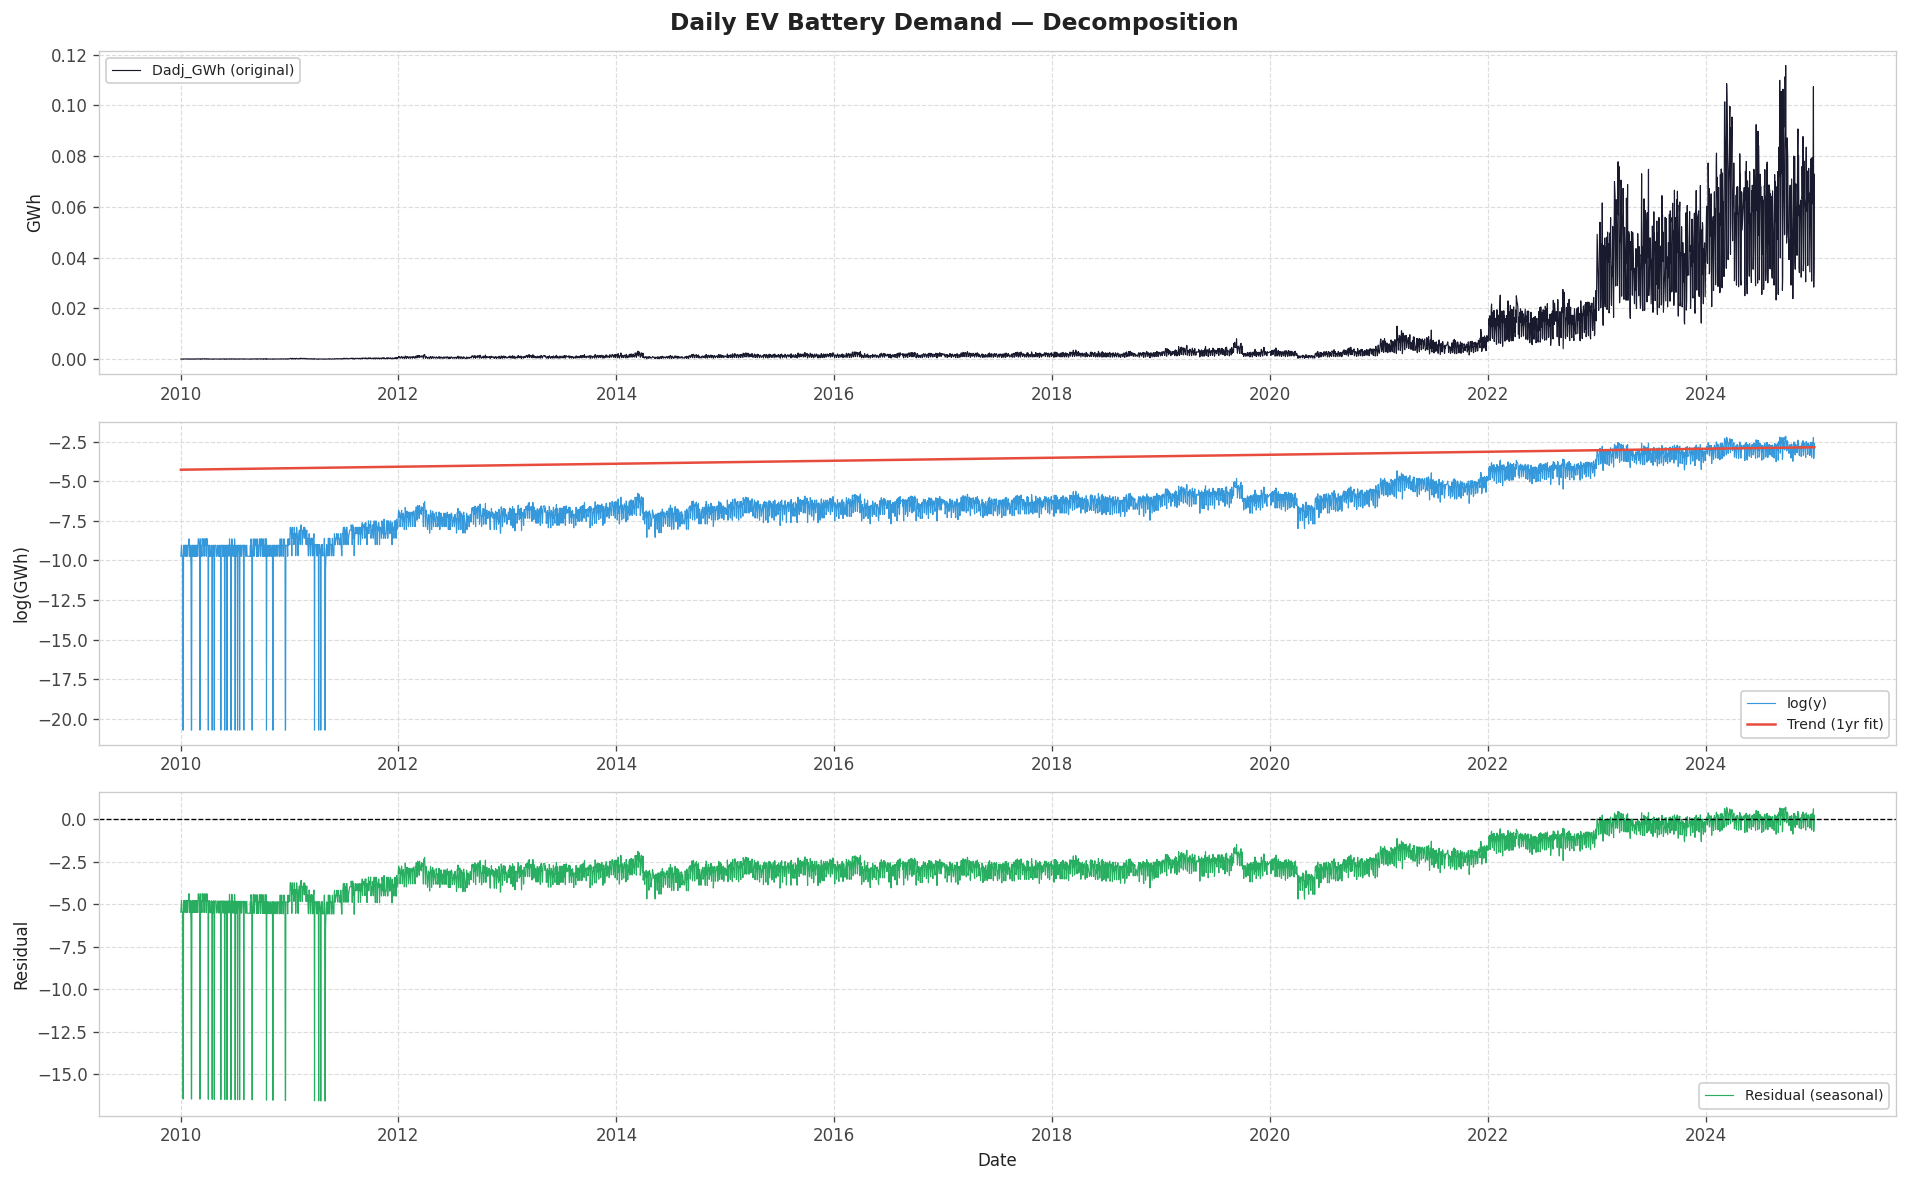

💾 Saved: 00_decomposition.png


In [7]:
fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=False)
fig.suptitle("Daily EV Battery Demand — Decomposition", fontsize=14, fontweight="bold")

axes[0].plot(df["date"], df[TARGET], color="#1a1a2e", lw=0.7, label="Dadj_GWh (original)")
axes[0].set_ylabel("GWh"); axes[0].legend()

axes[1].plot(df["date"], df["log_y"],   color="#3498db", lw=0.7, label="log(y)")
axes[1].plot(df["date"], df["trend"],   color="#e74c3c", lw=1.5, label="Trend (1yr fit)")
axes[1].set_ylabel("log(GWh)"); axes[1].legend()

axes[2].plot(df["date"], df["residual"], color="#27ae60", lw=0.7, label="Residual (seasonal)")
axes[2].axhline(0, color="black", lw=0.8, linestyle="--")
axes[2].set_ylabel("Residual"); axes[2].set_xlabel("Date"); axes[2].legend()

for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.xaxis.set_major_locator(mdates.YearLocator(2))

plt.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR,"00_decomposition.png"),dpi=150,bbox_inches="tight")
plt.show()
print("💾 Saved: 00_decomposition.png")


## § 4 — Feature Engineering

In [8]:
# Calendar harmonics — all cyclical (safe for any future date)
df["sin_doy"] = np.sin(2*np.pi*df["date"].dt.dayofyear/365)
df["cos_doy"] = np.cos(2*np.pi*df["date"].dt.dayofyear/365)
df["sin_dow"] = np.sin(2*np.pi*df["date"].dt.dayofweek/7)
df["cos_dow"] = np.cos(2*np.pi*df["date"].dt.dayofweek/7)
df["sin_mon"] = np.sin(2*np.pi*df["date"].dt.month/12)
df["cos_mon"] = np.cos(2*np.pi*df["date"].dt.month/12)
df["is_weekend"] = (df["date"].dt.dayofweek >= 5).astype(int)
df["quarter"]    = df["date"].dt.quarter

# Lagged RESIDUALS — residuals are stationary so safe for recursive forecast
# (they stay bounded unlike log(y) lags which grow forever)
for lag in [1, 2, 7, 14, 30]:
    df[f"res_lag_{lag}"] = df["residual"].shift(lag)

# Rolling stats of residuals
for w in [7, 30]:
    df[f"res_roll{w}_mean"] = df["residual"].shift(1).rolling(w).mean()
    df[f"res_roll{w}_std"]  = df["residual"].shift(1).rolling(w).std()

df = df.dropna().reset_index(drop=True)

FEATURE_COLS = (
    ["sin_doy","cos_doy","sin_dow","cos_dow","sin_mon","cos_mon","is_weekend","quarter"] +
    [f"res_lag_{l}" for l in [1,2,7,14,30]] +
    ["res_roll7_mean","res_roll7_std","res_roll30_mean","res_roll30_std"]
)

# ── Target: RESIDUALS (stationary, bounded)
X         = df[FEATURE_COLS].values
y_res     = df["residual"].values       # ← what models predict
y_trend   = df["trend"].values          # ← added back analytically
y_orig    = df[TARGET].values           # ← original GWh (for metrics)
dates_all = df["date"].values

print(f"Features : {len(FEATURE_COLS)}  →  {FEATURE_COLS}")
print(f"Samples  : {len(X)}")
print(f"Residual : {y_res.min():.4f} → {y_res.max():.4f}  (bounded ✅)")


Features : 17  →  ['sin_doy', 'cos_doy', 'sin_dow', 'cos_dow', 'sin_mon', 'cos_mon', 'is_weekend', 'quarter', 'res_lag_1', 'res_lag_2', 'res_lag_7', 'res_lag_14', 'res_lag_30', 'res_roll7_mean', 'res_roll7_std', 'res_roll30_mean', 'res_roll30_std']
Samples  : 5447
Residual : -16.5800 → 0.7181  (bounded ✅)


## § 5 — Train / Test Split

In [9]:
SPLIT = int(len(X) * 0.80)

X_train, X_test = X[:SPLIT], X[SPLIT:]
y_train, y_test = y_res[:SPLIT], y_res[SPLIT:]       # residuals
trend_train     = y_trend[:SPLIT]
trend_test      = y_trend[SPLIT:]
y_orig_test     = y_orig[SPLIT:]
dates_train     = dates_all[:SPLIT]
dates_test      = dates_all[SPLIT:]

print(f"Train : {len(X_train):,}  ({pd.Timestamp(dates_train[0]).date()} → {pd.Timestamp(dates_train[-1]).date()})")
print(f"Test  : {len(X_test):,}   ({pd.Timestamp(dates_test[0]).date()} → {pd.Timestamp(dates_test[-1]).date()})")

# Scale X only (residuals are already small, no need to scale y)
x_scaler = RobustScaler()
X_train_s = x_scaler.fit_transform(X_train)
X_test_s  = x_scaler.transform(X_test)

# Seasonal residual lookup (for lag seeding in forecast)
# Average residual per day-of-week from last year → bounded, stationary seed
dow_res_avg = df.iloc[-365:].groupby("dow")["residual"].mean().to_dict()

# Results store
RESULTS  = {}
ML_NAMES = ["LinearRegression","Ridge","RandomForest","SVR","XGBoost"]
DL_NAMES = ["ANN","SimpleRNN","LSTM","GRU","CNN"]

def store_result(name, y_true_orig, y_pred_orig):
    mae  = mean_absolute_error(y_true_orig, y_pred_orig)
    rmse = np.sqrt(mean_squared_error(y_true_orig, y_pred_orig))
    mape = mean_absolute_percentage_error(y_true_orig, y_pred_orig) * 100
    r2   = r2_score(y_true_orig, y_pred_orig)
    RESULTS[name] = {"y_pred":y_pred_orig,
                     "metrics":{"MAE":mae,"RMSE":rmse,"MAPE":mape,"R2":r2}}
    print(f"  {name:<22} MAE={mae:.6f}  RMSE={rmse:.6f}  MAPE={mape:.2f}%  R²={r2:.4f}")

print("\nReady.")


Train : 4,357  (2010-02-01 → 2022-01-05)
Test  : 1,090   (2022-01-06 → 2024-12-30)

Ready.


## § 6 — Plot Helper

In [10]:
def plot_model(name, y_pred_orig, dates_test_local,
               forecast_dates=None, forecast_vals=None):
    color = PALETTE.get(name, "#555")
    m     = RESULTS[name]["metrics"]
    label = (f"{name}\nR²={m['R2']:.4f} | RMSE={m['RMSE']:.6f}\n"
             f"MAE={m['MAE']:.6f} | MAPE={m['MAPE']:.2f}%")

    fig, (ax1, ax2) = plt.subplots(2,1, figsize=(17,8),
        gridspec_kw={"height_ratios":[3,1]}, facecolor="white")
    fig.suptitle(f"Model: {name}  —  Daily BEV Demand Forecast to 2035",
                 fontsize=13, fontweight="bold")

    ax1.plot(pd.to_datetime(dates_all), y_orig,
             color=PALETTE["Actual"], lw=0.7, alpha=0.65, label="Actual")
    ax1.plot(pd.to_datetime(dates_test_local), y_pred_orig,
             color=color, lw=1.8, linestyle="--", label=label)

    if forecast_dates is not None:
        ax1.plot(pd.to_datetime(forecast_dates), forecast_vals,
                 color=PALETTE["Forecast"], lw=2.0, label="Forecast → 2035")
        ax1.axvspan(pd.to_datetime(forecast_dates[0]),
                    pd.to_datetime(forecast_dates[-1]), alpha=0.05,
                    color=PALETTE["Forecast"])
    ax1.axvline(pd.Timestamp(dates_test_local[0]), color="#e74c3c",
                lw=1.2, linestyle=":", label="Train/Test split")
    ax1.set_ylabel("Dadj_GWh")
    ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax1.xaxis.set_major_locator(mdates.YearLocator(2))
    ax1.legend(loc="upper left")

    n = min(len(y_orig_test), len(y_pred_orig))
    res = y_orig_test[:n] - y_pred_orig[:n]
    ax2.fill_between(pd.to_datetime(dates_test_local[:n]), res, 0,
                     where=res>=0, color=color, alpha=0.45)
    ax2.fill_between(pd.to_datetime(dates_test_local[:n]), res, 0,
                     where=res<0,  color="#e74c3c", alpha=0.35)
    ax2.axhline(0, color="#333", lw=0.8, linestyle="--")
    ax2.set_ylabel("Residual (GWh)"); ax2.set_xlabel("Date")
    ax2.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax2.xaxis.set_major_locator(mdates.YearLocator(2))

    plt.tight_layout()
    path = os.path.join(FIGURES_DIR, f"{name}_forecast.png")
    fig.savefig(path, dpi=150, bbox_inches="tight", facecolor="white")
    print(f"  💾 {path}")
    plt.show()

print("✅  plot_model() ready")


✅  plot_model() ready


## § 7 — Future Feature Builder

In [11]:
def build_future_features(horizon_end="2035-12-31"):
    """
    Build feature rows for every future day.
    KEY: lag features use the SEASONAL AVERAGE residual for that day-of-week
         → bounded, stationary, no recursive explosion.
    Trend is computed analytically and NOT in the features.
    """
    last_date   = pd.Timestamp(dates_all[-1])
    t_last      = float(len(df) - 1)
    future_dts  = pd.date_range(last_date + pd.Timedelta(days=1),
                                horizon_end, freq="D")

    # Seed: last 30 actual residuals (for rolling features)
    res_seed = list(df["residual"].values[-30:])

    rows, trend_vals = [], []

    for step, dt in enumerate(future_dts):
        doy = dt.dayofyear;  dow = dt.dayofweek
        mon = dt.month;      qtr = dt.quarter

        sin_doy = np.sin(2*np.pi*doy/365); cos_doy = np.cos(2*np.pi*doy/365)
        sin_dow = np.sin(2*np.pi*dow/7);   cos_dow = np.cos(2*np.pi*dow/7)
        sin_mon = np.sin(2*np.pi*mon/12);  cos_mon = np.cos(2*np.pi*mon/12)
        is_wknd = int(dow >= 5)

        # Lag residuals: use seasonal avg for that day-of-week (bounded ✅)
        def seasonal_lag(n_days_back):
            target_dow = (dow - n_days_back) % 7
            return dow_res_avg.get(target_dow, 0.0)

        # Rolling from seed (bounded because seed contains real residuals ≈ [-1, 1])
        r7m  = float(np.mean(res_seed[-7:]))
        r7s  = float(np.std(res_seed[-7:]))  if len(res_seed)>1 else 0.
        r30m = float(np.mean(res_seed[-30:]))
        r30s = float(np.std(res_seed[-30:])) if len(res_seed)>1 else 0.

        row = [sin_doy, cos_doy, sin_dow, cos_dow, sin_mon, cos_mon,
               is_wknd, qtr,
               seasonal_lag(1),  seasonal_lag(2),  seasonal_lag(7),
               seasonal_lag(14), seasonal_lag(30),
               r7m, r7s, r30m, r30s]
        rows.append(row)

        # Trend for this future step (analytical)
        t_future = t_last + step + 1
        trend_vals.append(SLOPE * t_future + INTERCEPT)

        # Update seed with seasonal avg residual for next step's rolling window
        res_seed.append(dow_res_avg.get(dow, 0.0))

    X_fut   = np.array(rows, dtype=np.float64)
    X_fut   = np.nan_to_num(X_fut, nan=0.0, posinf=0.0, neginf=0.0)
    X_fut_s = np.clip(x_scaler.transform(X_fut), -5., 5.)

    return list(future_dts), X_fut_s, np.array(trend_vals)


def ml_forecast(model):
    """ML forecast: predict residuals → add trend → exp → GWh"""
    fut_dts, X_fut_s, trend_fut = build_future_features()
    res_pred = model.predict(X_fut_s)                     # predicted residual
    log_pred = trend_fut + res_pred                        # trend + residual
    return fut_dts, np.maximum(np.exp(log_pred), 0.0)     # back to GWh


def ml_test_predict(model):
    """Test prediction in original GWh."""
    res_pred = model.predict(X_test_s)
    log_pred = trend_test + res_pred
    return np.maximum(np.exp(log_pred), 0.0)


print(f"✅  Forecast builder ready")
print(f"    Future steps: {len(pd.date_range(pd.Timestamp(dates_all[-1])+pd.Timedelta(days=1),'2035-12-31',freq='D'))}")


✅  Forecast builder ready
    Future steps: 4018


## § 8 — Optuna-Tuned ML Models

  MACHINE LEARNING — OPTUNA TUNING

► LinearRegression
  LinearRegression       MAE=0.009960  RMSE=0.014091  MAPE=26.96%  R²=0.6085
  💾 C:\Users\bouda\Desktop\TimeSeries_Project/figures/LinearRegression_forecast.png


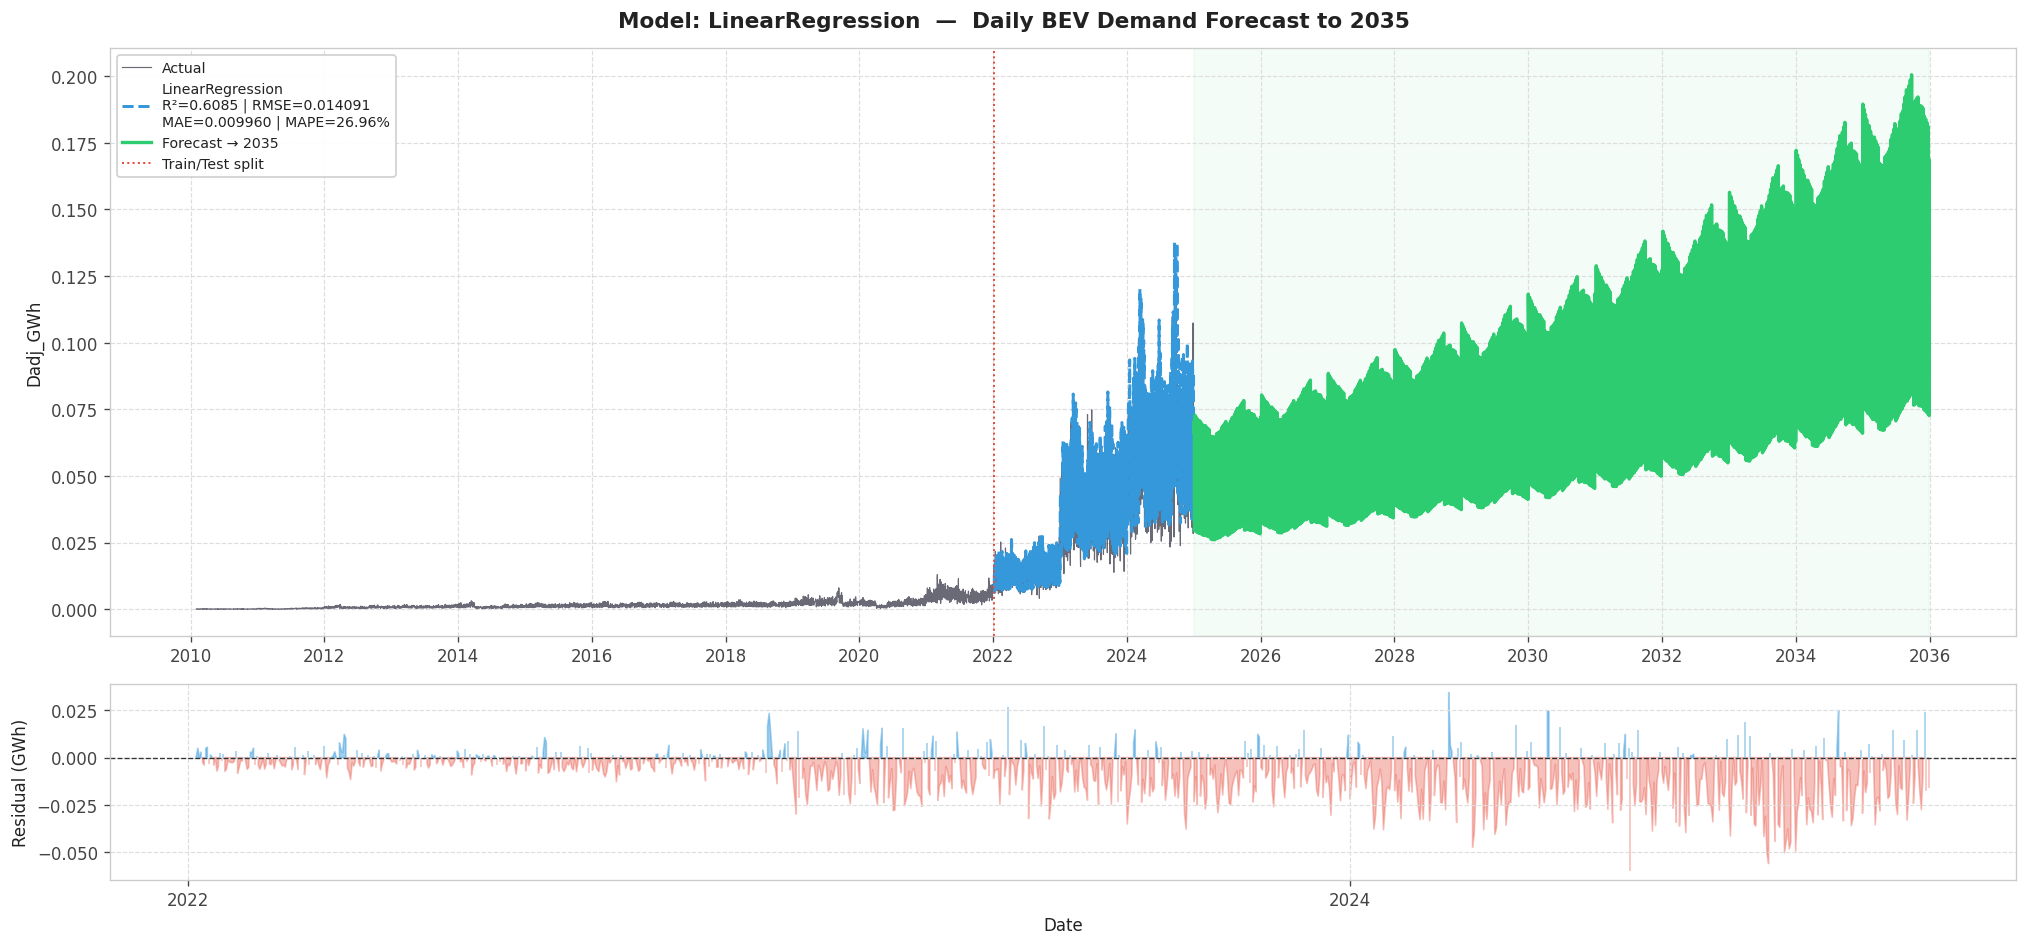

In [12]:
N_TRIALS = 40
print("="*65)
print("  MACHINE LEARNING — OPTUNA TUNING")
print("="*65)

def eval_model(model):
    model.fit(X_train_s, y_train)
    return ml_test_predict(model)

# ── 1. Linear Regression (no tuning needed)
print("\n► LinearRegression")
lr = LinearRegression()
lr.fit(X_train_s, y_train)
y_pred = ml_test_predict(lr)
store_result("LinearRegression", y_orig_test, y_pred)
fut_d, fut_v = ml_forecast(lr)
RESULTS["LinearRegression"]["forecast_dates"] = fut_d
RESULTS["LinearRegression"]["forecast_vals"]  = fut_v
plot_model("LinearRegression", y_pred, dates_test, fut_d, fut_v)



► Ridge (Optuna)
  Best: {'alpha': 925.9210355813477}
  Ridge                  MAE=0.006621  RMSE=0.009317  MAPE=18.55%  R²=0.8289
  💾 C:\Users\bouda\Desktop\TimeSeries_Project/figures/Ridge_forecast.png


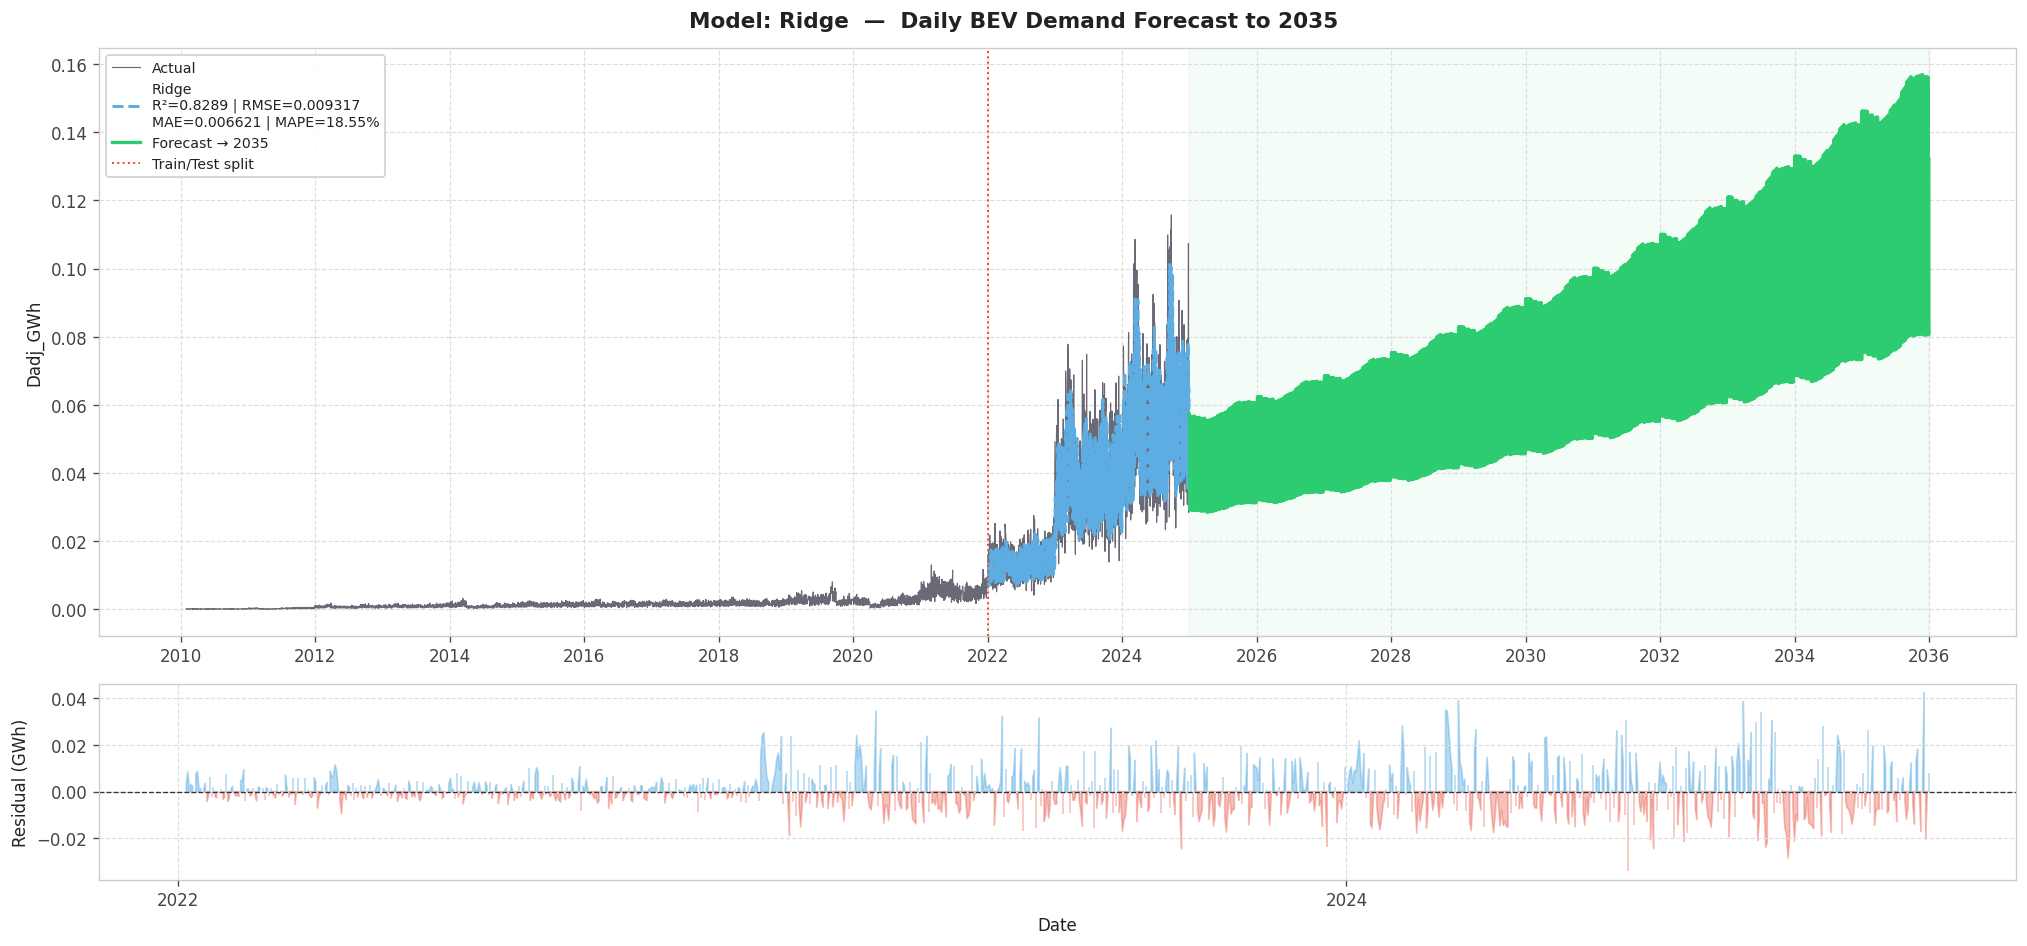

In [13]:
# ── 2. Ridge
print("\n► Ridge (Optuna)")
def ridge_obj(trial):
    m = Ridge(alpha=trial.suggest_float("alpha",1e-3,1e3,log=True))
    m.fit(X_train_s, y_train)
    return mean_squared_error(y_orig_test, ml_test_predict(m))

s = optuna.create_study(direction="minimize",sampler=optuna.samplers.TPESampler(seed=SEED))
s.optimize(ridge_obj, n_trials=N_TRIALS, show_progress_bar=False)
print(f"  Best: {s.best_params}")
ridge = Ridge(**s.best_params)
ridge.fit(X_train_s, y_train)
y_pred = ml_test_predict(ridge)
store_result("Ridge", y_orig_test, y_pred)
fut_d, fut_v = ml_forecast(ridge)
RESULTS["Ridge"]["forecast_dates"] = fut_d
RESULTS["Ridge"]["forecast_vals"]  = fut_v
plot_model("Ridge", y_pred, dates_test, fut_d, fut_v)



► RandomForest (Optuna)
  Best: {'n_estimators': 196, 'max_depth': 8, 'min_samples_leaf': 1, 'max_features': 0.5}
  RandomForest           MAE=0.027958  RMSE=0.034937  MAPE=63.94%  R²=-1.4063
  💾 C:\Users\bouda\Desktop\TimeSeries_Project/figures/RandomForest_forecast.png


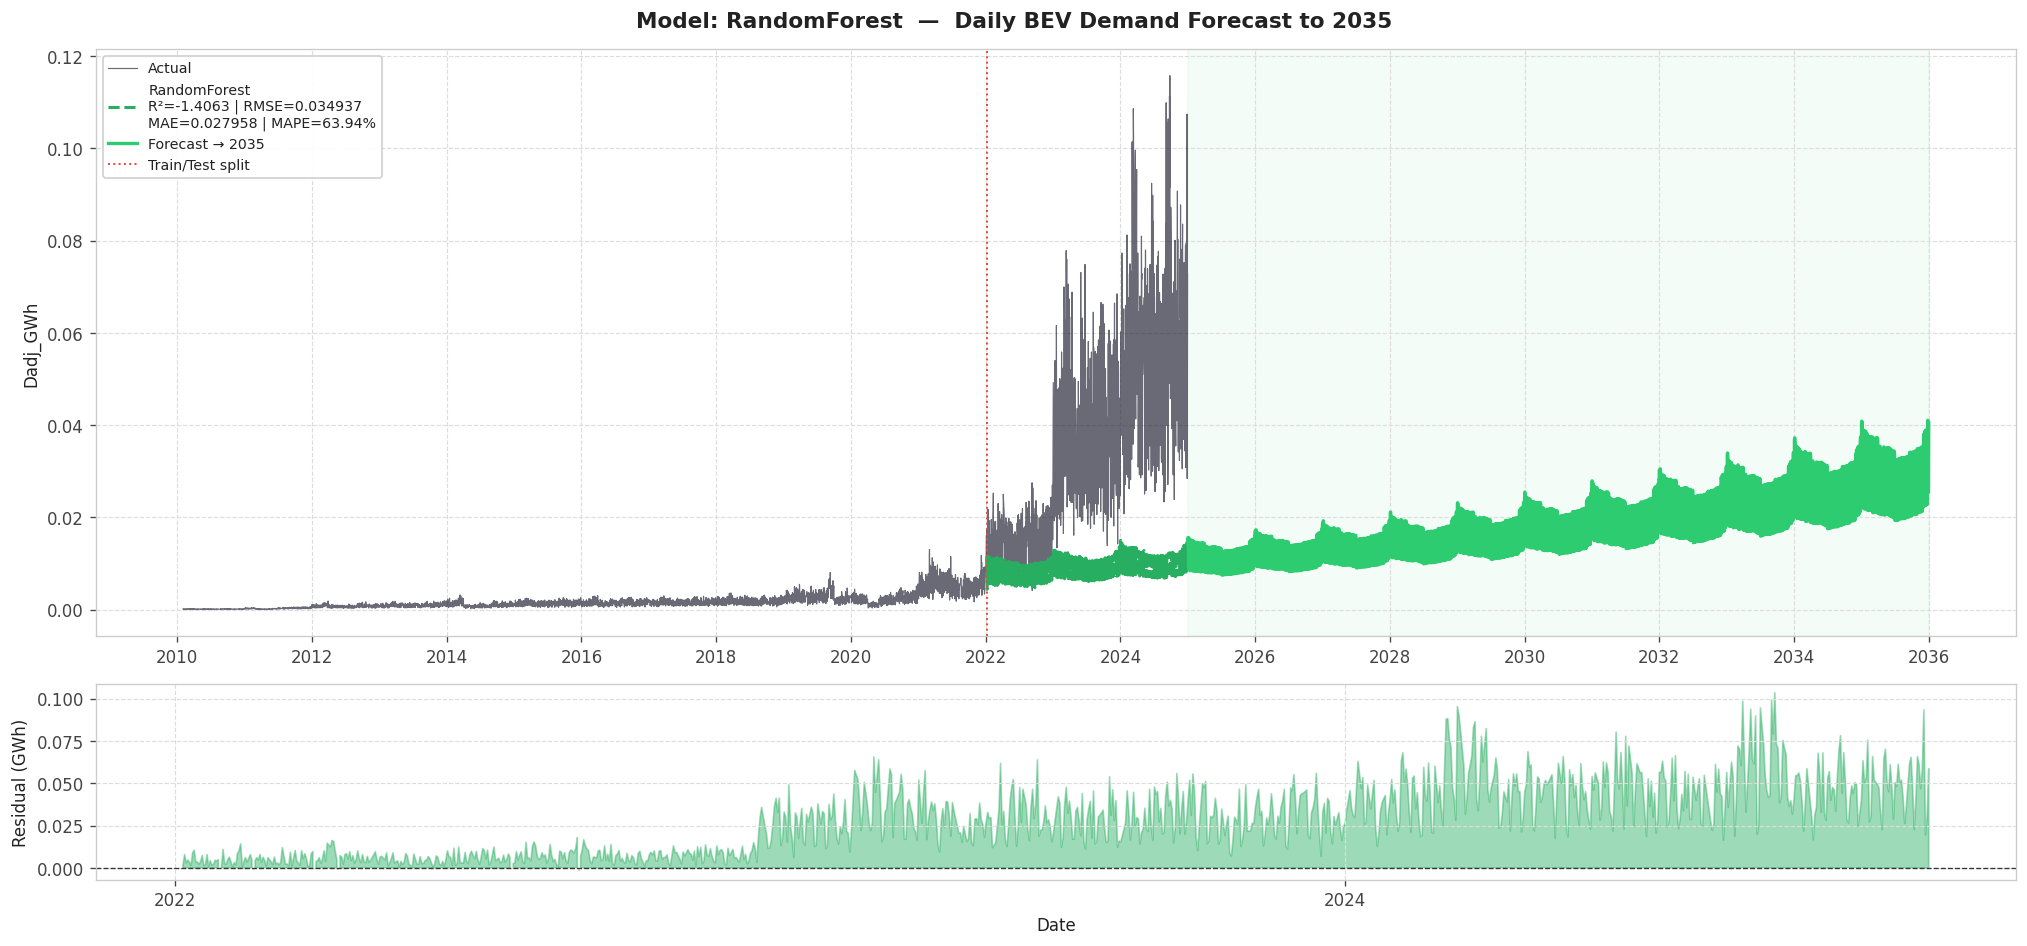

In [14]:
# ── 3. Random Forest
print("\n► RandomForest (Optuna)")
def rf_obj(trial):
    m = RandomForestRegressor(
        n_estimators=trial.suggest_int("n_estimators",100,400),
        max_depth=trial.suggest_int("max_depth",4,20),
        min_samples_leaf=trial.suggest_int("min_samples_leaf",1,10),
        max_features=trial.suggest_categorical("max_features",["sqrt","log2",0.5]),
        random_state=SEED, n_jobs=-1)
    m.fit(X_train_s, y_train)
    return mean_squared_error(y_orig_test, ml_test_predict(m))

s = optuna.create_study(direction="minimize",sampler=optuna.samplers.TPESampler(seed=SEED))
s.optimize(rf_obj, n_trials=N_TRIALS, show_progress_bar=False)
print(f"  Best: {s.best_params}")
rf = RandomForestRegressor(**s.best_params, random_state=SEED, n_jobs=-1)
rf.fit(X_train_s, y_train)
y_pred = ml_test_predict(rf)
store_result("RandomForest", y_orig_test, y_pred)
fut_d, fut_v = ml_forecast(rf)
RESULTS["RandomForest"]["forecast_dates"] = fut_d
RESULTS["RandomForest"]["forecast_vals"]  = fut_v
plot_model("RandomForest", y_pred, dates_test, fut_d, fut_v)



► SVR (Optuna)
  Best: {'C': 56.147107609060235, 'epsilon': 0.0010856209584676917, 'gamma': 'scale'}
  SVR                    MAE=0.008445  RMSE=0.011922  MAPE=23.28%  R²=0.7198
  💾 C:\Users\bouda\Desktop\TimeSeries_Project/figures/SVR_forecast.png


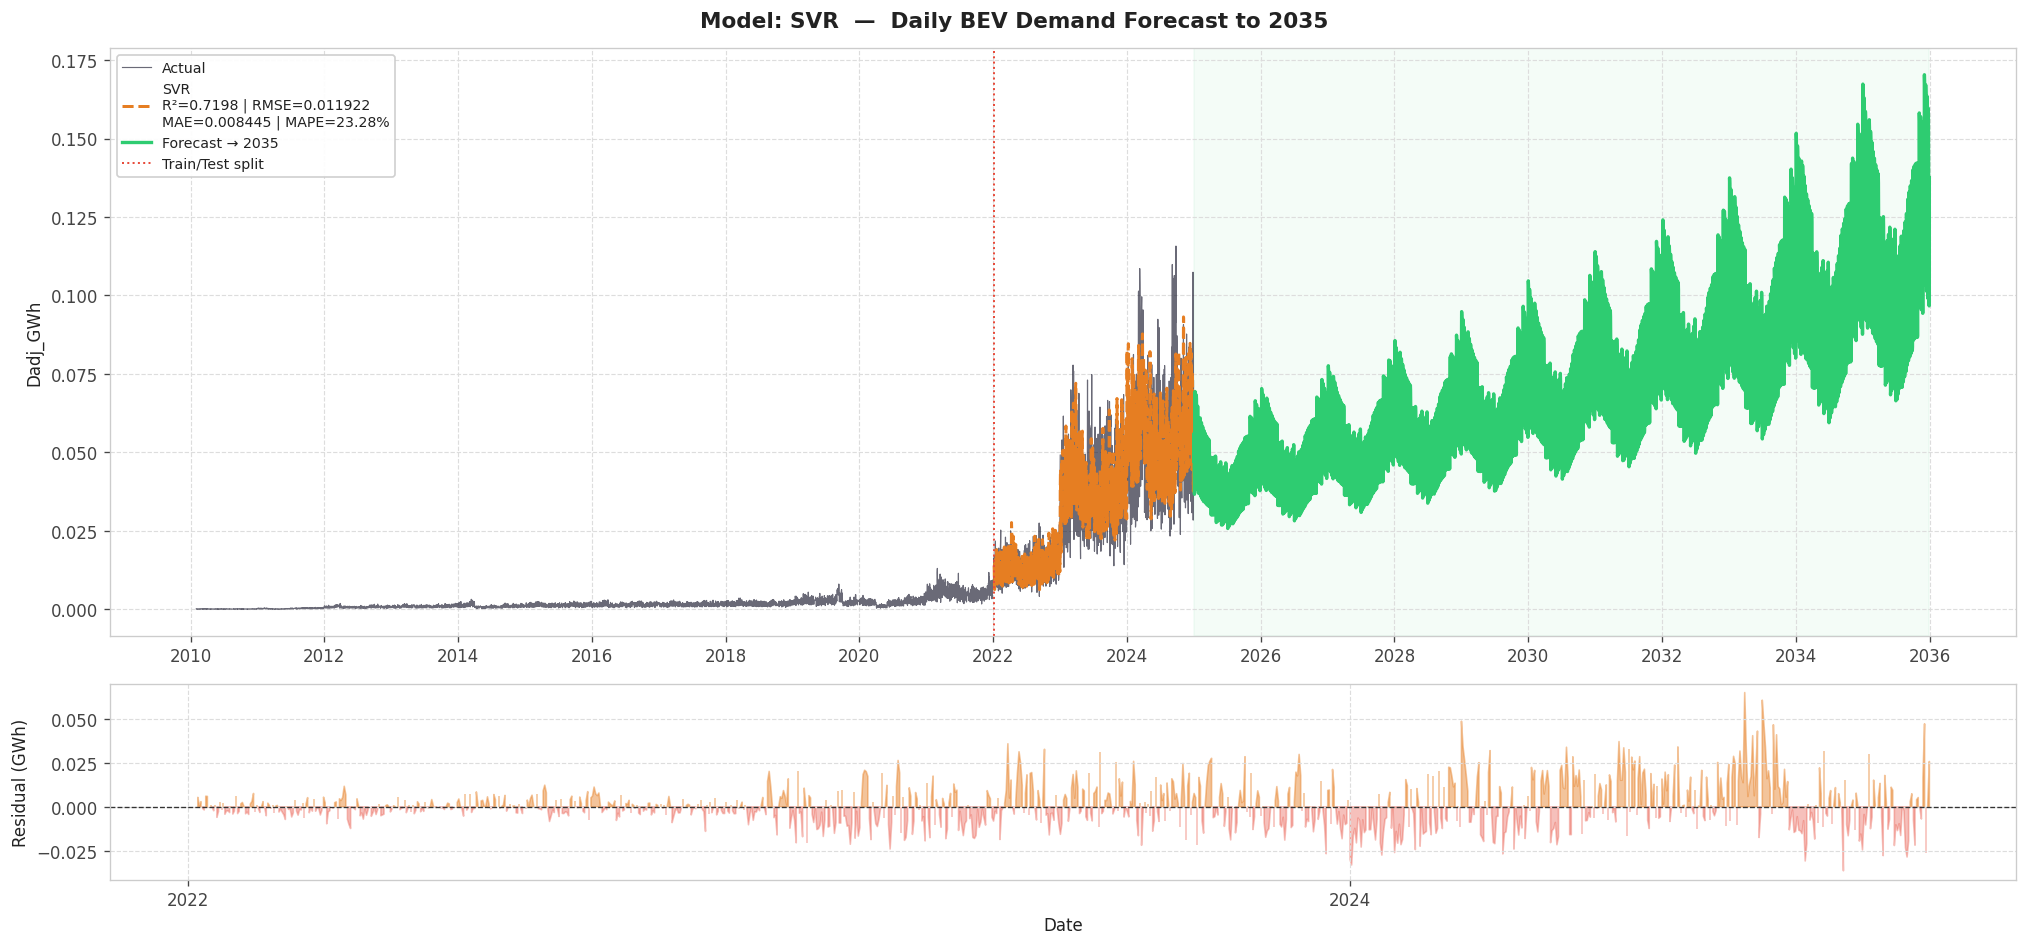

In [15]:
# ── 4. SVR
print("\n► SVR (Optuna)")
def svr_obj(trial):
    m = SVR(C=trial.suggest_float("C",0.1,100,log=True),
            epsilon=trial.suggest_float("epsilon",1e-4,0.5,log=True),
            gamma=trial.suggest_categorical("gamma",["scale","auto"]))
    m.fit(X_train_s, y_train)
    return mean_squared_error(y_orig_test, ml_test_predict(m))

s = optuna.create_study(direction="minimize",sampler=optuna.samplers.TPESampler(seed=SEED))
s.optimize(svr_obj, n_trials=N_TRIALS, show_progress_bar=False)
print(f"  Best: {s.best_params}")
svr = SVR(**s.best_params)
svr.fit(X_train_s, y_train)
y_pred = ml_test_predict(svr)
store_result("SVR", y_orig_test, y_pred)
fut_d, fut_v = ml_forecast(svr)
RESULTS["SVR"]["forecast_dates"] = fut_d
RESULTS["SVR"]["forecast_vals"]  = fut_v
plot_model("SVR", y_pred, dates_test, fut_d, fut_v)



► XGBoost (Optuna)
  Best: {'n_estimators': 514, 'max_depth': 4, 'learning_rate': 0.04666963767236924, 'subsample': 0.836965827544817, 'colsample_bytree': 0.6185801650879991}
  XGBoost                MAE=0.028997  RMSE=0.035976  MAPE=67.06%  R²=-1.5516
  💾 C:\Users\bouda\Desktop\TimeSeries_Project/figures/XGBoost_forecast.png


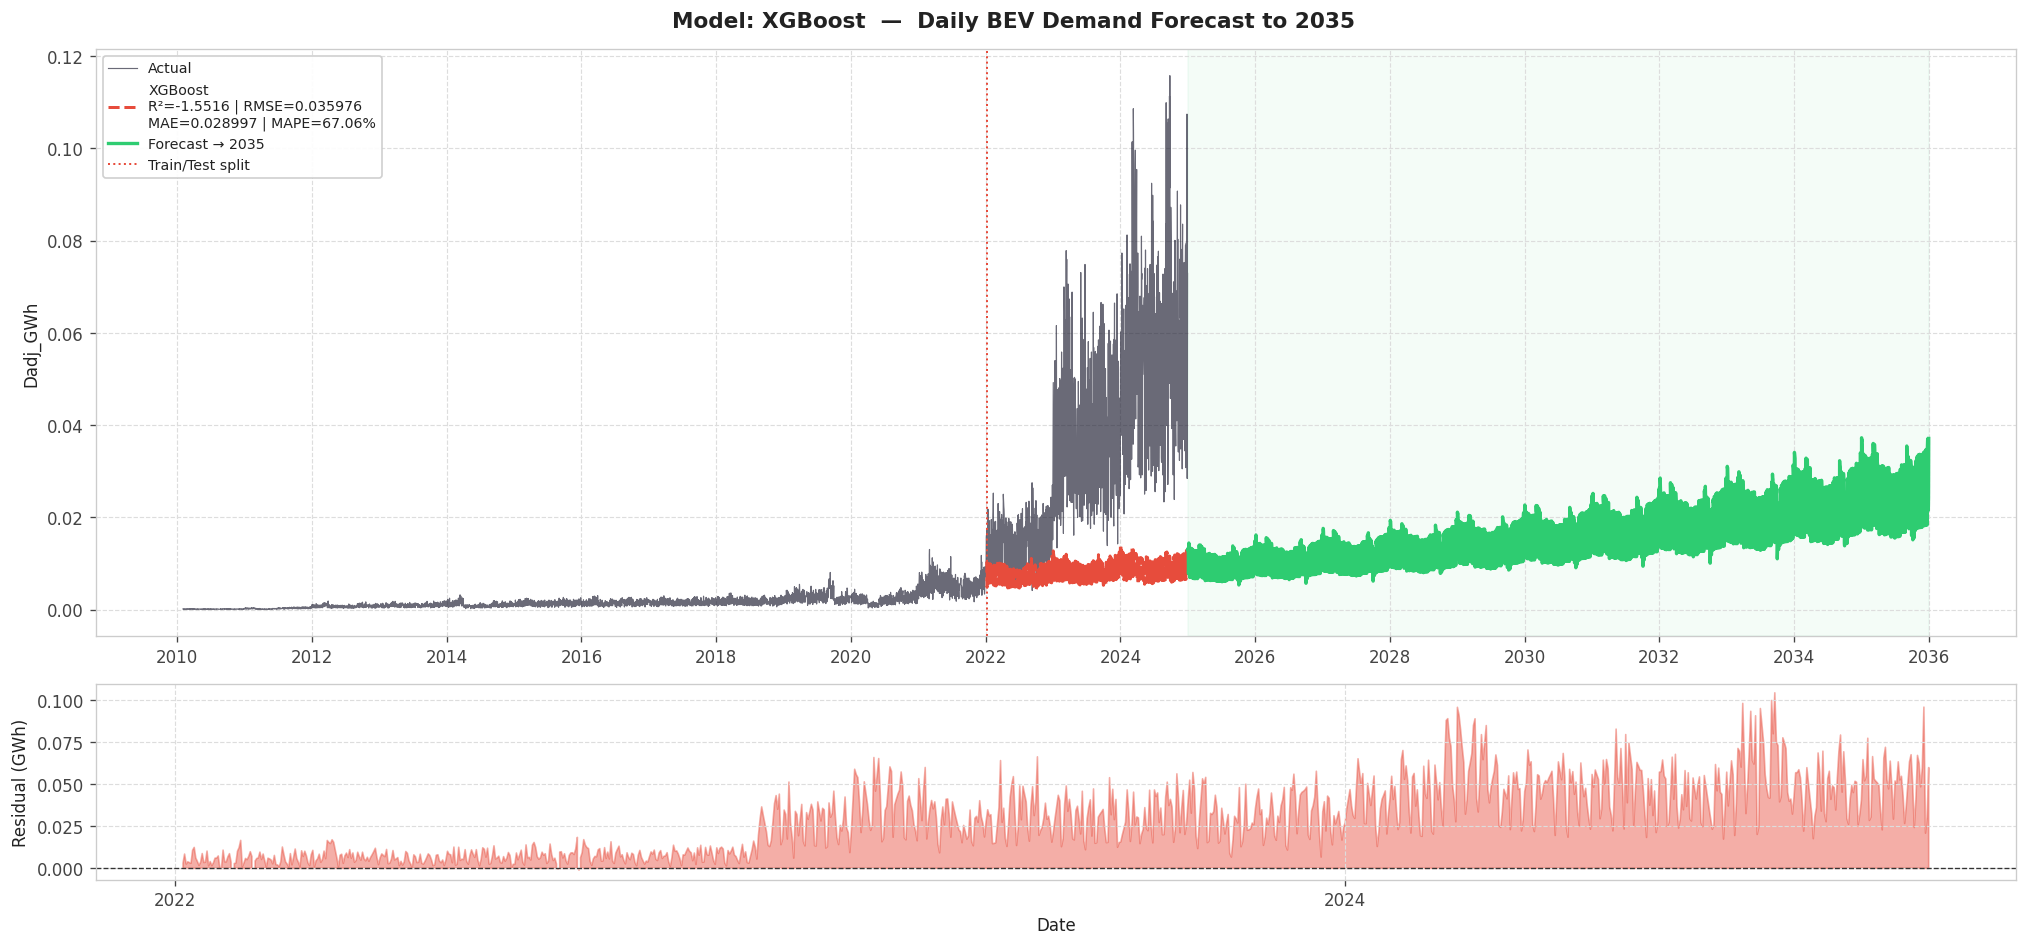


✅  All ML models done.


In [16]:
# ── 5. XGBoost
print("\n► XGBoost (Optuna)")
def xgb_obj(trial):
    m = xgb.XGBRegressor(
        n_estimators=trial.suggest_int("n_estimators",200,600),
        max_depth=trial.suggest_int("max_depth",3,9),
        learning_rate=trial.suggest_float("learning_rate",0.01,0.2,log=True),
        subsample=trial.suggest_float("subsample",0.6,1.0),
        colsample_bytree=trial.suggest_float("colsample_bytree",0.6,1.0),
        random_state=SEED, verbosity=0, n_jobs=-1)
    m.fit(X_train_s, y_train)
    return mean_squared_error(y_orig_test, ml_test_predict(m))

s = optuna.create_study(direction="minimize",sampler=optuna.samplers.TPESampler(seed=SEED))
s.optimize(xgb_obj, n_trials=N_TRIALS, show_progress_bar=False)
print(f"  Best: {s.best_params}")
xgb_model = xgb.XGBRegressor(**s.best_params, random_state=SEED, verbosity=0, n_jobs=-1)
xgb_model.fit(X_train_s, y_train)
y_pred = ml_test_predict(xgb_model)
store_result("XGBoost", y_orig_test, y_pred)
fut_d, fut_v = ml_forecast(xgb_model)
RESULTS["XGBoost"]["forecast_dates"] = fut_d
RESULTS["XGBoost"]["forecast_vals"]  = fut_v
plot_model("XGBoost", y_pred, dates_test, fut_d, fut_v)

print("\n✅  All ML models done.")


## § 9 — Deep Learning Models

In [17]:
# DL models predict residuals from sequences of residuals
# Residuals are bounded → recursive DL forecast stays bounded ✅
SEQ    = 60
N_FEAT = X_train_s.shape[1]

def make_sequences(Xs, ys, seq):
    Xo, yo = [], []
    for i in range(seq, len(Xs)):
        Xo.append(Xs[i-seq:i]); yo.append(ys[i])
    return np.array(Xo), np.array(yo)

Xs_tr, ys_tr = make_sequences(
    np.vstack([X_train_s, X_test_s[:SEQ]]),
    np.concatenate([y_train, y_test[:SEQ]]), SEQ)
Xs_te, ys_te = make_sequences(
    np.vstack([X_train_s[-SEQ:], X_test_s]),
    np.concatenate([y_train[-SEQ:], y_test]), SEQ)

N_TE           = len(Xs_te)
dates_test_dl  = dates_all[SPLIT: SPLIT + N_TE]
trend_test_dl  = y_trend[SPLIT: SPLIT + N_TE]
y_orig_test_dl = y_orig[SPLIT: SPLIT + N_TE]

print(f"Xs_tr : {Xs_tr.shape}")
print(f"Xs_te : {Xs_te.shape}  → aligned with {len(dates_test_dl)} test dates ✅")

ES  = EarlyStopping(patience=12, restore_best_weights=True)
RLR = ReduceLROnPlateau(patience=6, factor=0.4, min_lr=1e-6, verbose=0)
CB  = [ES, RLR]
EPOCHS, BATCH = 100, 64

def dl_test_predict(model, is_flat=False):
    Xs = Xs_te.reshape(len(Xs_te),-1) if is_flat else Xs_te
    res_pred = model.predict(Xs, verbose=0).ravel()
    log_pred = trend_test_dl + res_pred
    return np.maximum(np.exp(log_pred), 0.)

def dl_forecast(model, is_flat=False, horizon_end="2035-12-31"):
    """
    DL forecast on RESIDUALS (stationary → safe for recursive prediction).
    Seed: last SEQ future feature rows from build_future_features().
    At each step: model predicts next residual → add to seed window.
    Since residuals are bounded [-1,1], recursion stays stable ✅
    """
    fut_dts, X_fut_s, trend_fut = build_future_features(horizon_end)
    n   = len(fut_dts)

    # Seed window from the last SEQ test feature rows
    seed = list(X_test_s[-SEQ:])   # list of feature vectors

    preds_res = []
    for i in range(n):
        window  = np.array(seed[-SEQ:], dtype=np.float64)
        inp     = window.reshape(1,-1) if is_flat else window.reshape(1,SEQ,N_FEAT)
        p_res   = float(model.predict(inp, verbose=0)[0][0])
        # Clamp residual to training range (safety net)
        p_res   = float(np.clip(p_res,
                                df["residual"].min()*1.1,
                                df["residual"].max()*1.1))
        preds_res.append(p_res)
        seed.append(X_fut_s[i])    # advance window with future seasonal features

    log_pred  = trend_fut + np.array(preds_res)
    return fut_dts, np.maximum(np.exp(log_pred), 0.)

print("✅  DL helpers ready")


Xs_tr : (4357, 60, 17)
Xs_te : (1090, 60, 17)  → aligned with 1090 test dates ✅
✅  DL helpers ready


► ANN
  ANN                    MAE=0.035324  RMSE=0.042365  MAPE=86.60%  R²=-2.5383
  💾 C:\Users\bouda\Desktop\TimeSeries_Project/figures/ANN_forecast.png


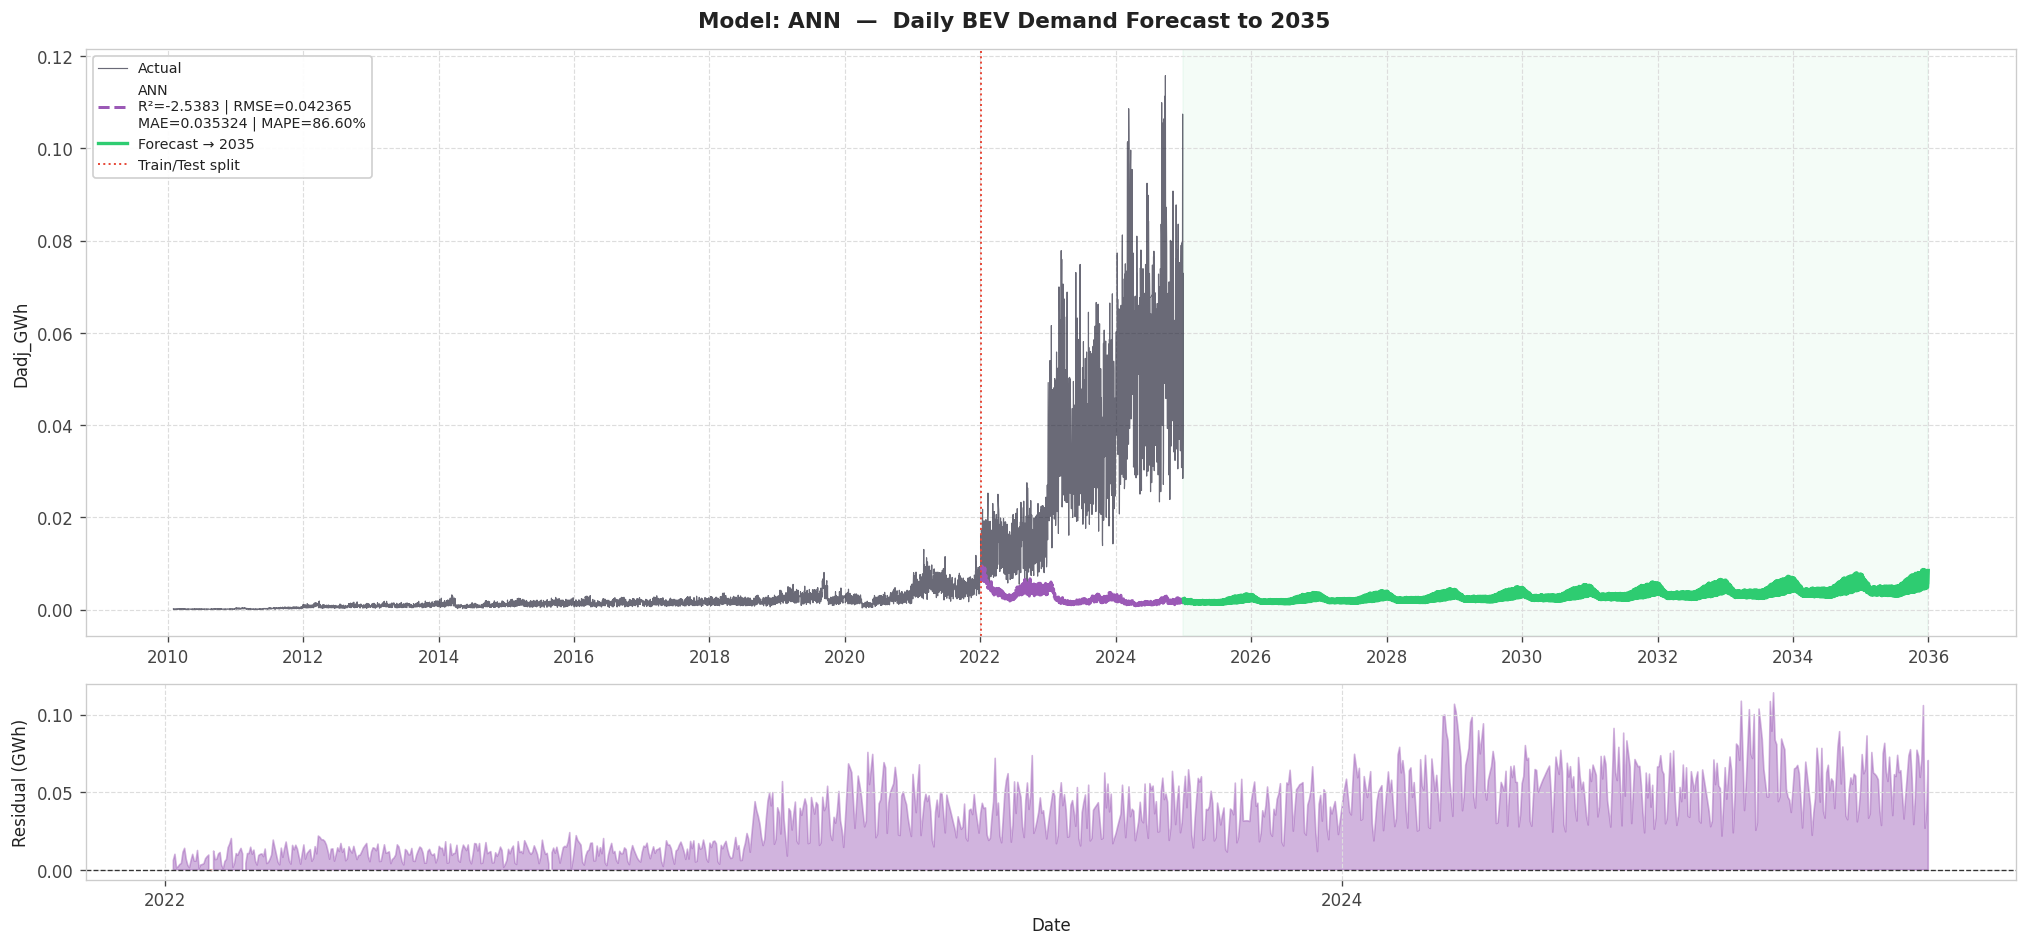

In [18]:
# ── ANN
print("► ANN")
Xs_tr_f = Xs_tr.reshape(len(Xs_tr),-1)
Xs_te_f = Xs_te.reshape(len(Xs_te),-1)

ann = Sequential([
    Dense(256,activation="relu",input_shape=(SEQ*N_FEAT,)),
    Dropout(0.3), Dense(128,activation="relu"),
    Dropout(0.2), Dense(64,activation="relu"),
    Dense(1)
])
ann.compile(optimizer=Adam(5e-4),loss="huber")
ann.fit(Xs_tr_f,ys_tr,epochs=EPOCHS,batch_size=BATCH,
        validation_split=0.15,callbacks=CB,verbose=0)

y_pred = dl_test_predict(ann, is_flat=True)
store_result("ANN", y_orig_test_dl, y_pred)
fut_d, fut_v = dl_forecast(ann, is_flat=True)
RESULTS["ANN"]["forecast_dates"]=fut_d; RESULTS["ANN"]["forecast_vals"]=fut_v
plot_model("ANN", y_pred, dates_test_dl, fut_d, fut_v)


► SimpleRNN
  SimpleRNN              MAE=1.365923  RMSE=1.444239  MAPE=6493.85%  R²=-4111.0984
  💾 C:\Users\bouda\Desktop\TimeSeries_Project/figures/SimpleRNN_forecast.png


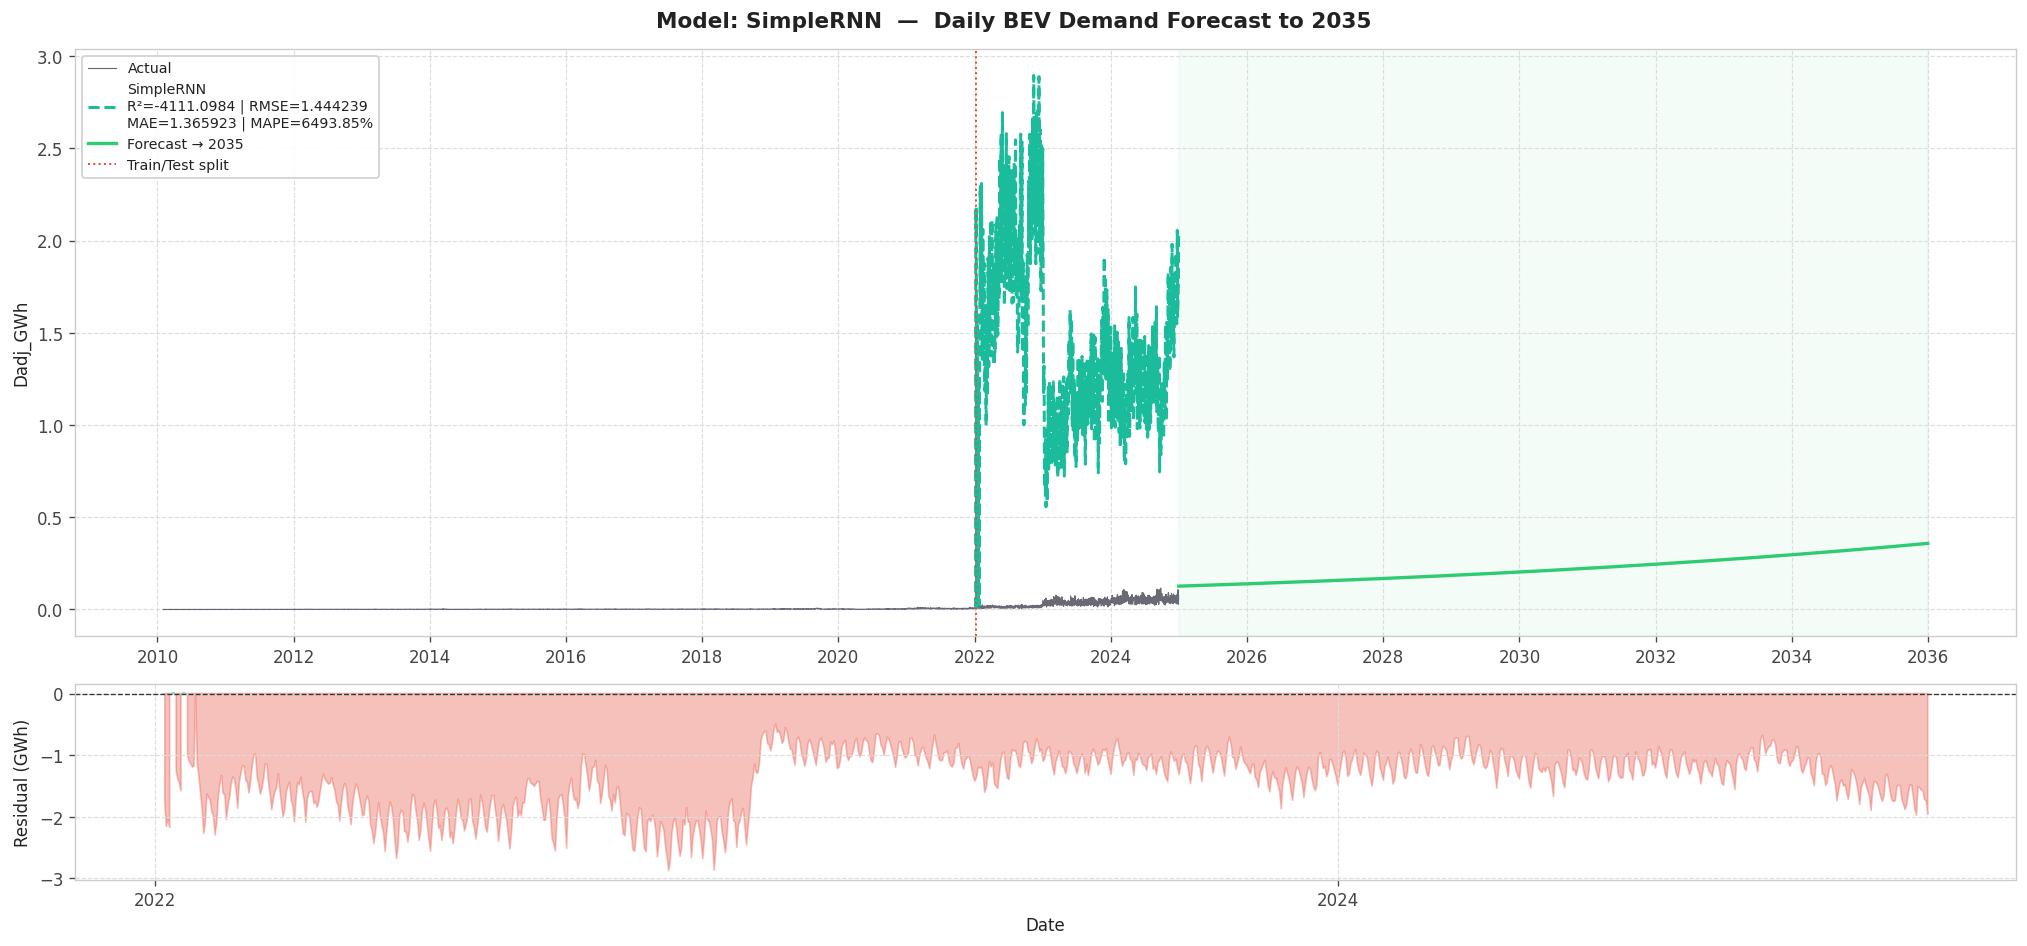

In [19]:
# ── SimpleRNN
print("► SimpleRNN")
rnn = Sequential([
    SimpleRNN(128,return_sequences=True,input_shape=(SEQ,N_FEAT)),
    Dropout(0.2), SimpleRNN(64), Dropout(0.2),
    Dense(32,activation="relu"), Dense(1)
])
rnn.compile(optimizer=Adam(5e-4),loss="huber")
rnn.fit(Xs_tr,ys_tr,epochs=EPOCHS,batch_size=BATCH,
        validation_split=0.15,callbacks=CB,verbose=0)

y_pred = dl_test_predict(rnn)
store_result("SimpleRNN", y_orig_test_dl, y_pred)
fut_d, fut_v = dl_forecast(rnn)
RESULTS["SimpleRNN"]["forecast_dates"]=fut_d; RESULTS["SimpleRNN"]["forecast_vals"]=fut_v
plot_model("SimpleRNN", y_pred, dates_test_dl, fut_d, fut_v)


► LSTM
  LSTM                   MAE=0.025300  RMSE=0.032502  MAPE=55.61%  R²=-1.0826
  💾 C:\Users\bouda\Desktop\TimeSeries_Project/figures/LSTM_forecast.png


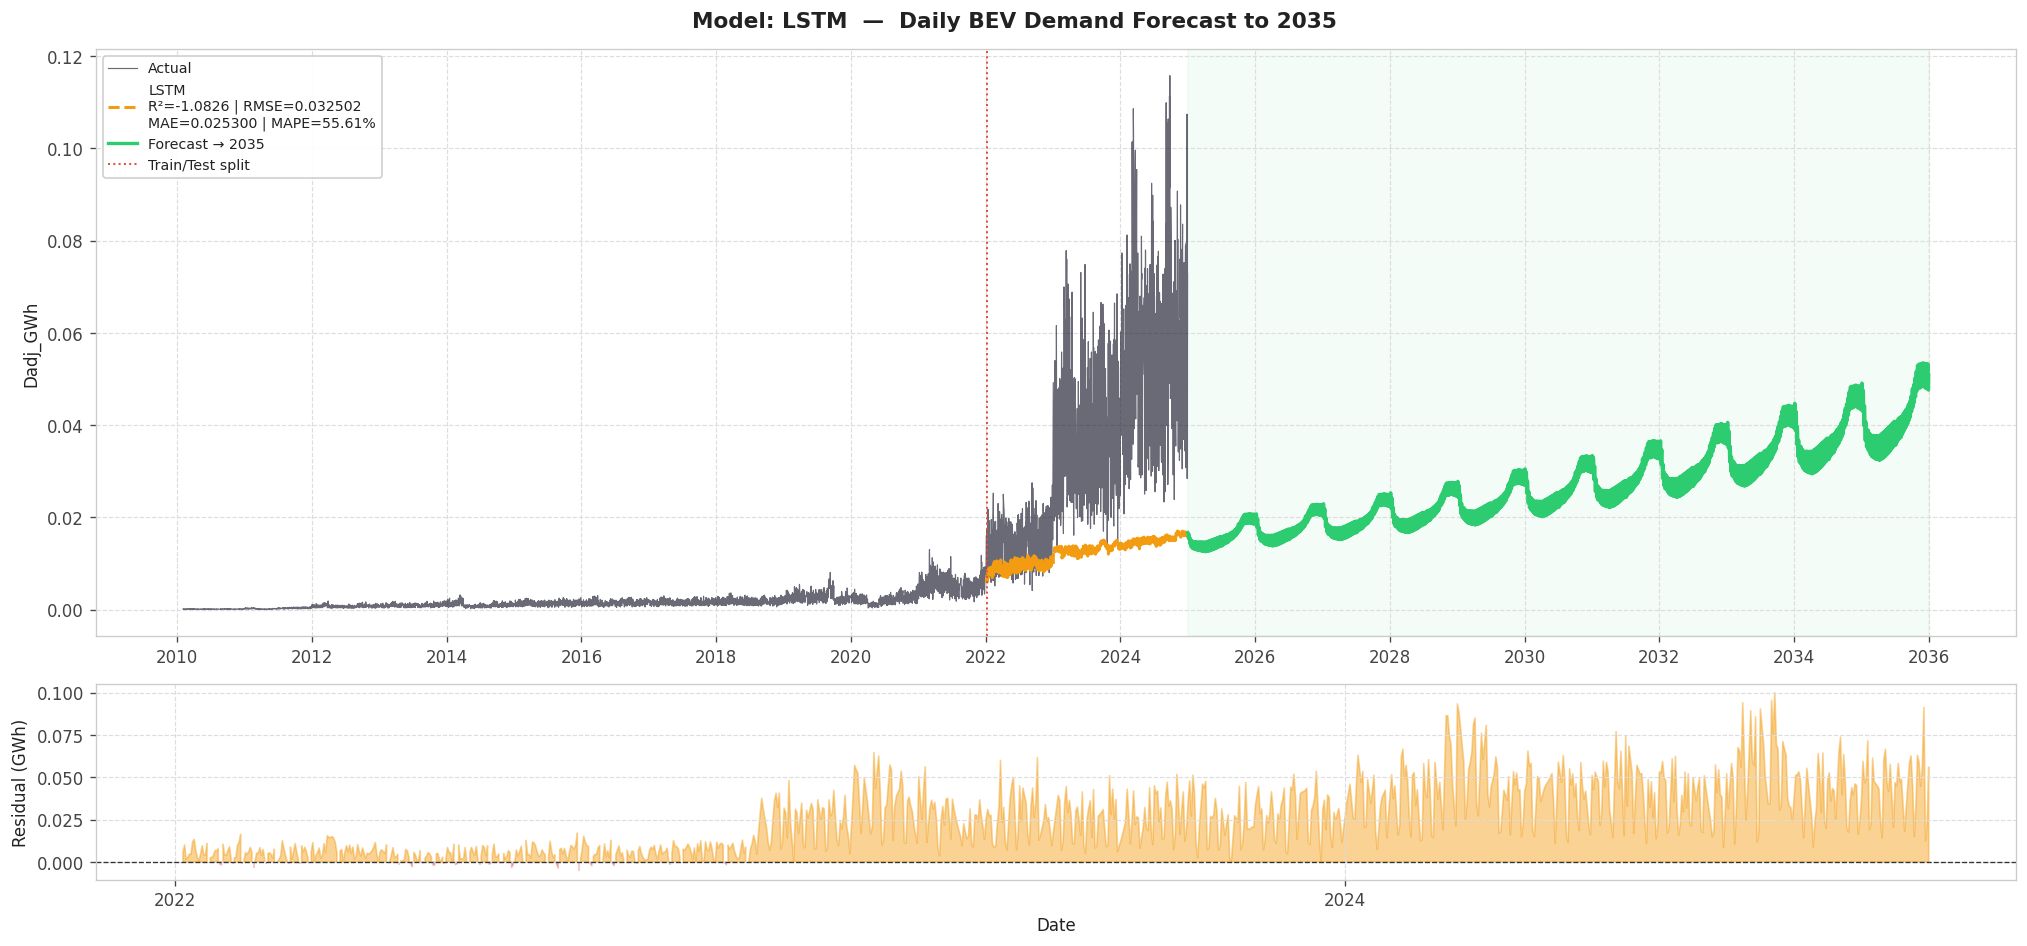

In [20]:
# ── LSTM
print("► LSTM")
lstm = Sequential([
    LSTM(128,return_sequences=True,input_shape=(SEQ,N_FEAT)),
    Dropout(0.2), LSTM(64), Dropout(0.2),
    Dense(32,activation="relu"), Dense(1)
])
lstm.compile(optimizer=Adam(5e-4),loss="huber")
lstm.fit(Xs_tr,ys_tr,epochs=EPOCHS,batch_size=BATCH,
         validation_split=0.15,callbacks=CB,verbose=0)

y_pred = dl_test_predict(lstm)
store_result("LSTM", y_orig_test_dl, y_pred)
fut_d, fut_v = dl_forecast(lstm)
RESULTS["LSTM"]["forecast_dates"]=fut_d; RESULTS["LSTM"]["forecast_vals"]=fut_v
plot_model("LSTM", y_pred, dates_test_dl, fut_d, fut_v)


► GRU
  GRU                    MAE=0.036339  RMSE=0.042681  MAPE=93.87%  R²=-2.5913
  💾 C:\Users\bouda\Desktop\TimeSeries_Project/figures/GRU_forecast.png


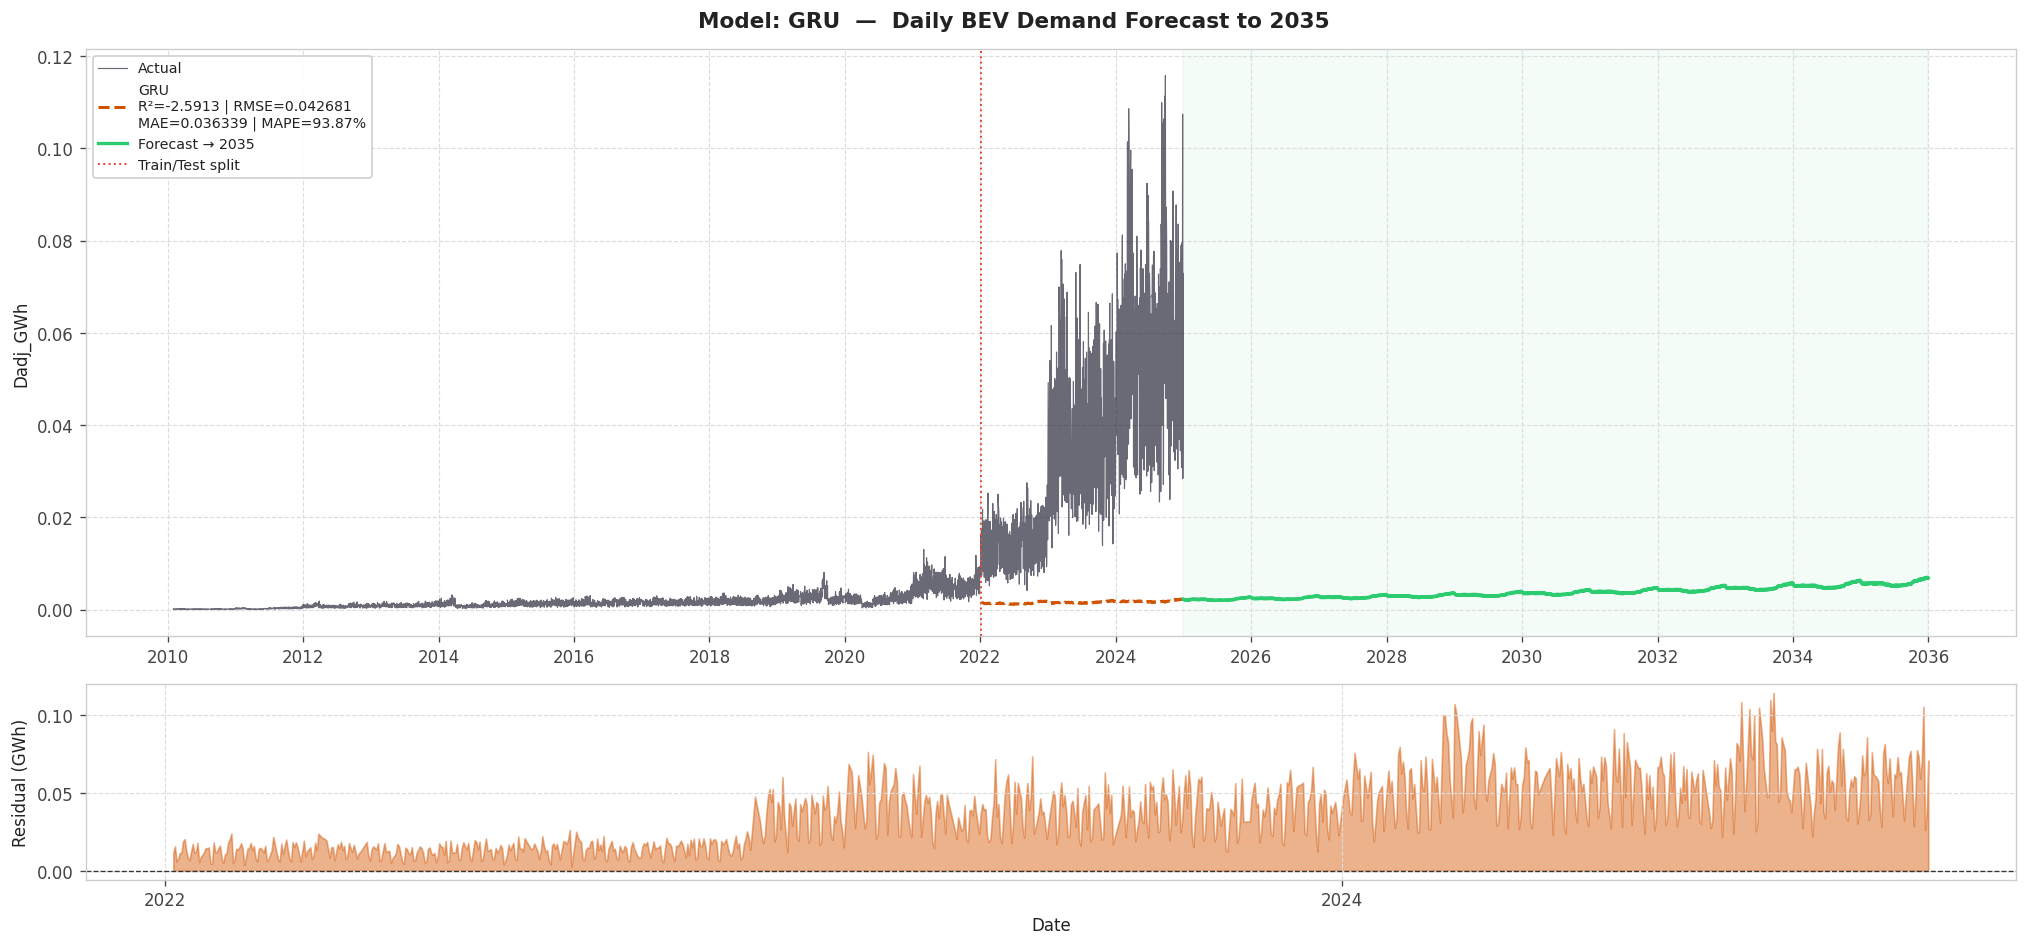

In [21]:
# ── GRU
print("► GRU")
gru = Sequential([
    GRU(128,return_sequences=True,input_shape=(SEQ,N_FEAT)),
    Dropout(0.2), GRU(64), Dropout(0.2),
    Dense(32,activation="relu"), Dense(1)
])
gru.compile(optimizer=Adam(5e-4),loss="huber")
gru.fit(Xs_tr,ys_tr,epochs=EPOCHS,batch_size=BATCH,
        validation_split=0.15,callbacks=CB,verbose=0)

y_pred = dl_test_predict(gru)
store_result("GRU", y_orig_test_dl, y_pred)
fut_d, fut_v = dl_forecast(gru)
RESULTS["GRU"]["forecast_dates"]=fut_d; RESULTS["GRU"]["forecast_vals"]=fut_v
plot_model("GRU", y_pred, dates_test_dl, fut_d, fut_v)


► CNN
  CNN                    MAE=0.035648  RMSE=0.042400  MAPE=89.47%  R²=-2.5442
  💾 C:\Users\bouda\Desktop\TimeSeries_Project/figures/CNN_forecast.png


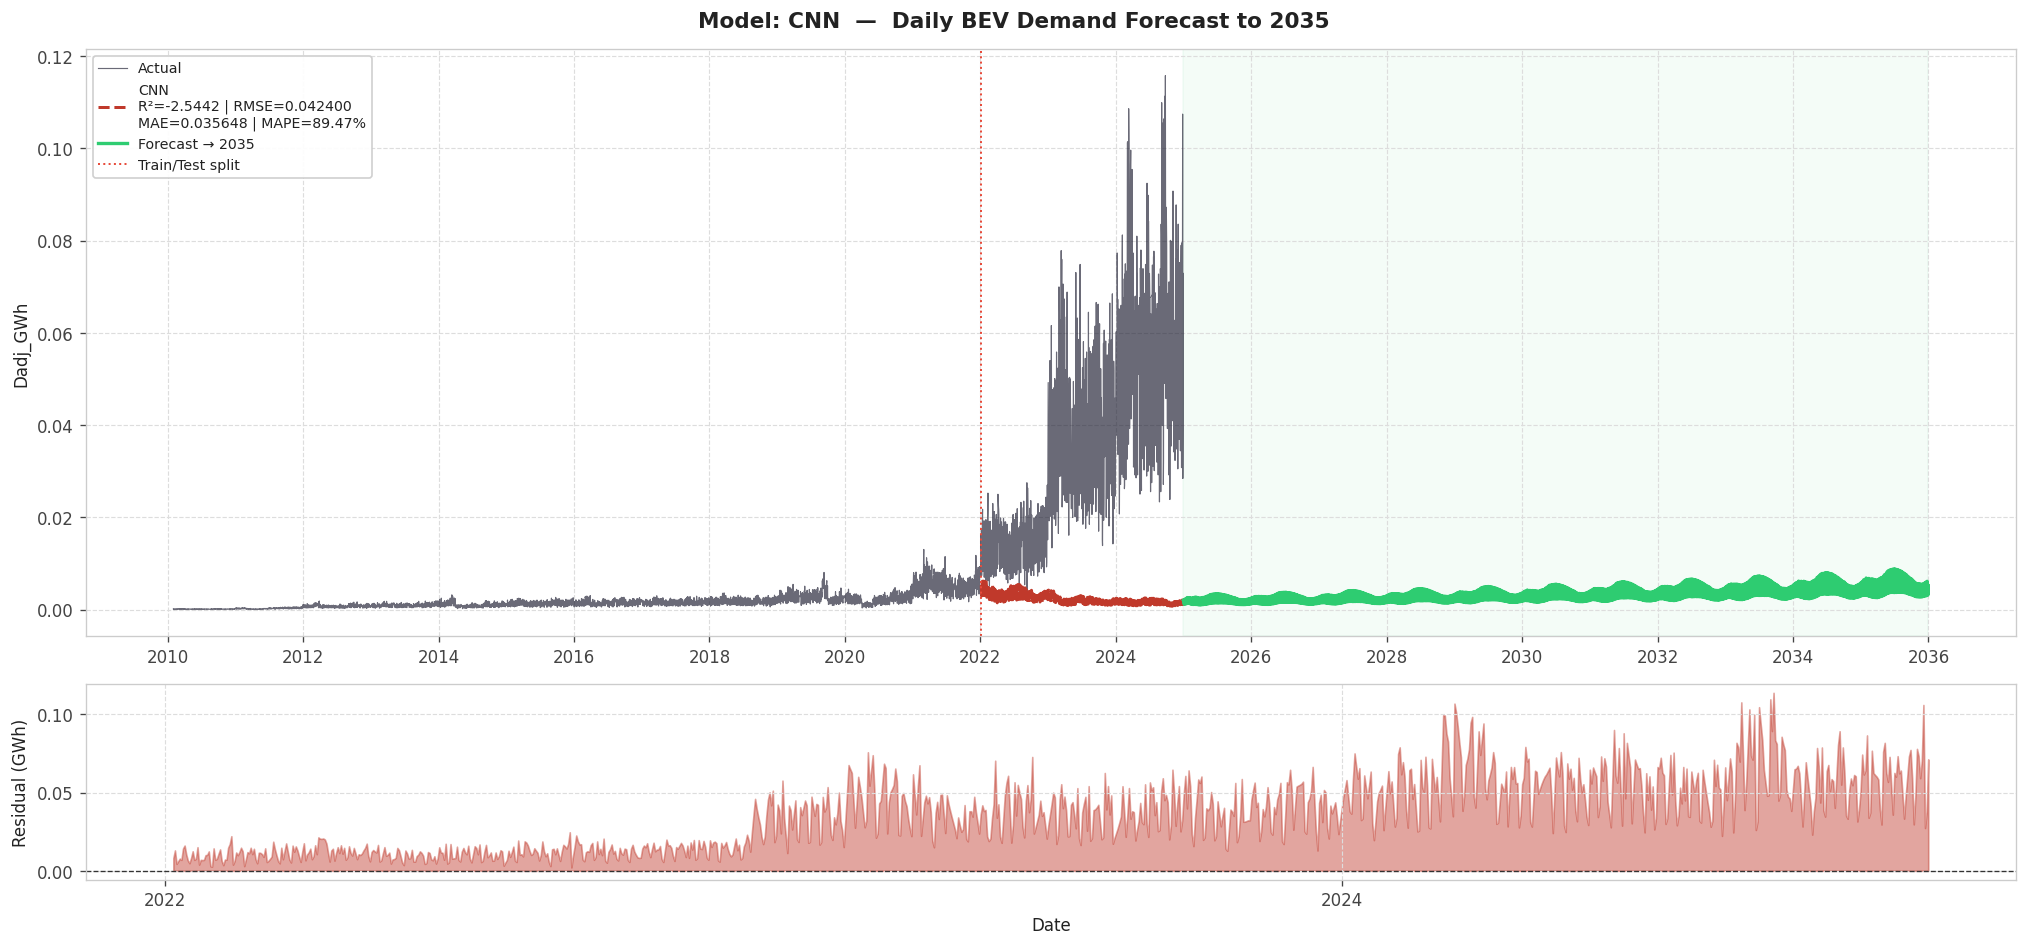


✅  All DL models done.


In [22]:
# ── CNN
print("► CNN")
cnn = Sequential([
    Conv1D(128,kernel_size=7,activation="relu",padding="same",input_shape=(SEQ,N_FEAT)),
    Dropout(0.2), Conv1D(64,kernel_size=5,activation="relu",padding="same"),
    Dropout(0.2), Conv1D(32,kernel_size=3,activation="relu",padding="same"),
    Flatten(), Dense(64,activation="relu"), Dropout(0.15),
    Dense(32,activation="relu"), Dense(1)
])
cnn.compile(optimizer=Adam(5e-4),loss="huber")
cnn.fit(Xs_tr,ys_tr,epochs=EPOCHS,batch_size=BATCH,
        validation_split=0.15,callbacks=CB,verbose=0)

y_pred = dl_test_predict(cnn)
store_result("CNN", y_orig_test_dl, y_pred)
fut_d, fut_v = dl_forecast(cnn)
RESULTS["CNN"]["forecast_dates"]=fut_d; RESULTS["CNN"]["forecast_vals"]=fut_v
plot_model("CNN", y_pred, dates_test_dl, fut_d, fut_v)

print("\n✅  All DL models done.")


## § 10 — Model Comparison

In [23]:
rows = []
for name in ML_NAMES + DL_NAMES:
    m = RESULTS[name]["metrics"]
    rows.append({"Model":name,"Type":"ML" if name in ML_NAMES else "DL",
                 "MAE":round(m["MAE"],6),"RMSE":round(m["RMSE"],6),
                 "MAPE":round(m["MAPE"],3),"R²":round(m["R2"],4)})
summary = (pd.DataFrame(rows).sort_values("R²",ascending=False)
             .reset_index(drop=True))
summary.index += 1
print("\n📊  LEADERBOARD")
print(summary.to_string())



📊  LEADERBOARD
               Model Type       MAE      RMSE      MAPE         R²
1              Ridge   ML  0.006621  0.009317    18.546     0.8289
2                SVR   ML  0.008445  0.011922    23.282     0.7198
3   LinearRegression   ML  0.009960  0.014091    26.956     0.6085
4               LSTM   DL  0.025300  0.032502    55.612    -1.0826
5       RandomForest   ML  0.027958  0.034937    63.936    -1.4063
6            XGBoost   ML  0.028997  0.035976    67.065    -1.5516
7                ANN   DL  0.035324  0.042365    86.601    -2.5383
8                CNN   DL  0.035648  0.042400    89.472    -2.5442
9                GRU   DL  0.036339  0.042681    93.872    -2.5913
10         SimpleRNN   DL  1.365923  1.444239  6493.848 -4111.0984


In [ ]:
# Fig A — Bar charts
fig, axes = plt.subplots(2,2,figsize=(18,10),facecolor="white")
fig.suptitle("Model Comparison — All Metrics",fontsize=14,fontweight="bold")
for ax,(col,title,hi) in zip(axes.flat,[
        ("R²","R² (↑ better)",True),("RMSE","RMSE (↓ better)",False),
        ("MAE","MAE (↓ better)",False),("MAPE","MAPE % (↓ better)",False)]):
    vals=[]; models=[]
    for _,r in summary.iterrows():
        vals.append(r[col]); models.append(r["Model"])
    vals=np.array(vals)
    bars=ax.bar(models,vals,color=[PALETTE.get(m,"#888") for m in models],
                edgecolor="#333",lw=0.6,alpha=0.88)
    bi=int(vals.argmax()) if hi else int(vals.argmin())
    bars[bi].set_edgecolor("#e74c3c"); bars[bi].set_linewidth(2.5)
    for bar,val,mn in zip(bars,vals,models):
        r2v=summary[summary["Model"]==mn]["R²"].values[0]
        ax.text(bar.get_x()+bar.get_width()/2,bar.get_height()+max(vals)*0.01,
                f"{val:.5f}\nR²={r2v:.4f}",ha="center",va="bottom",fontsize=6.5,fontweight="bold")
    ax.set_title(title); ax.tick_params(axis="x",rotation=35,labelsize=8)
    ax.set_ylim(0,max(vals)*1.25)
plt.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR,"comparison_A_metrics.png"),
            dpi=150,bbox_inches="tight",facecolor="white")
plt.show()


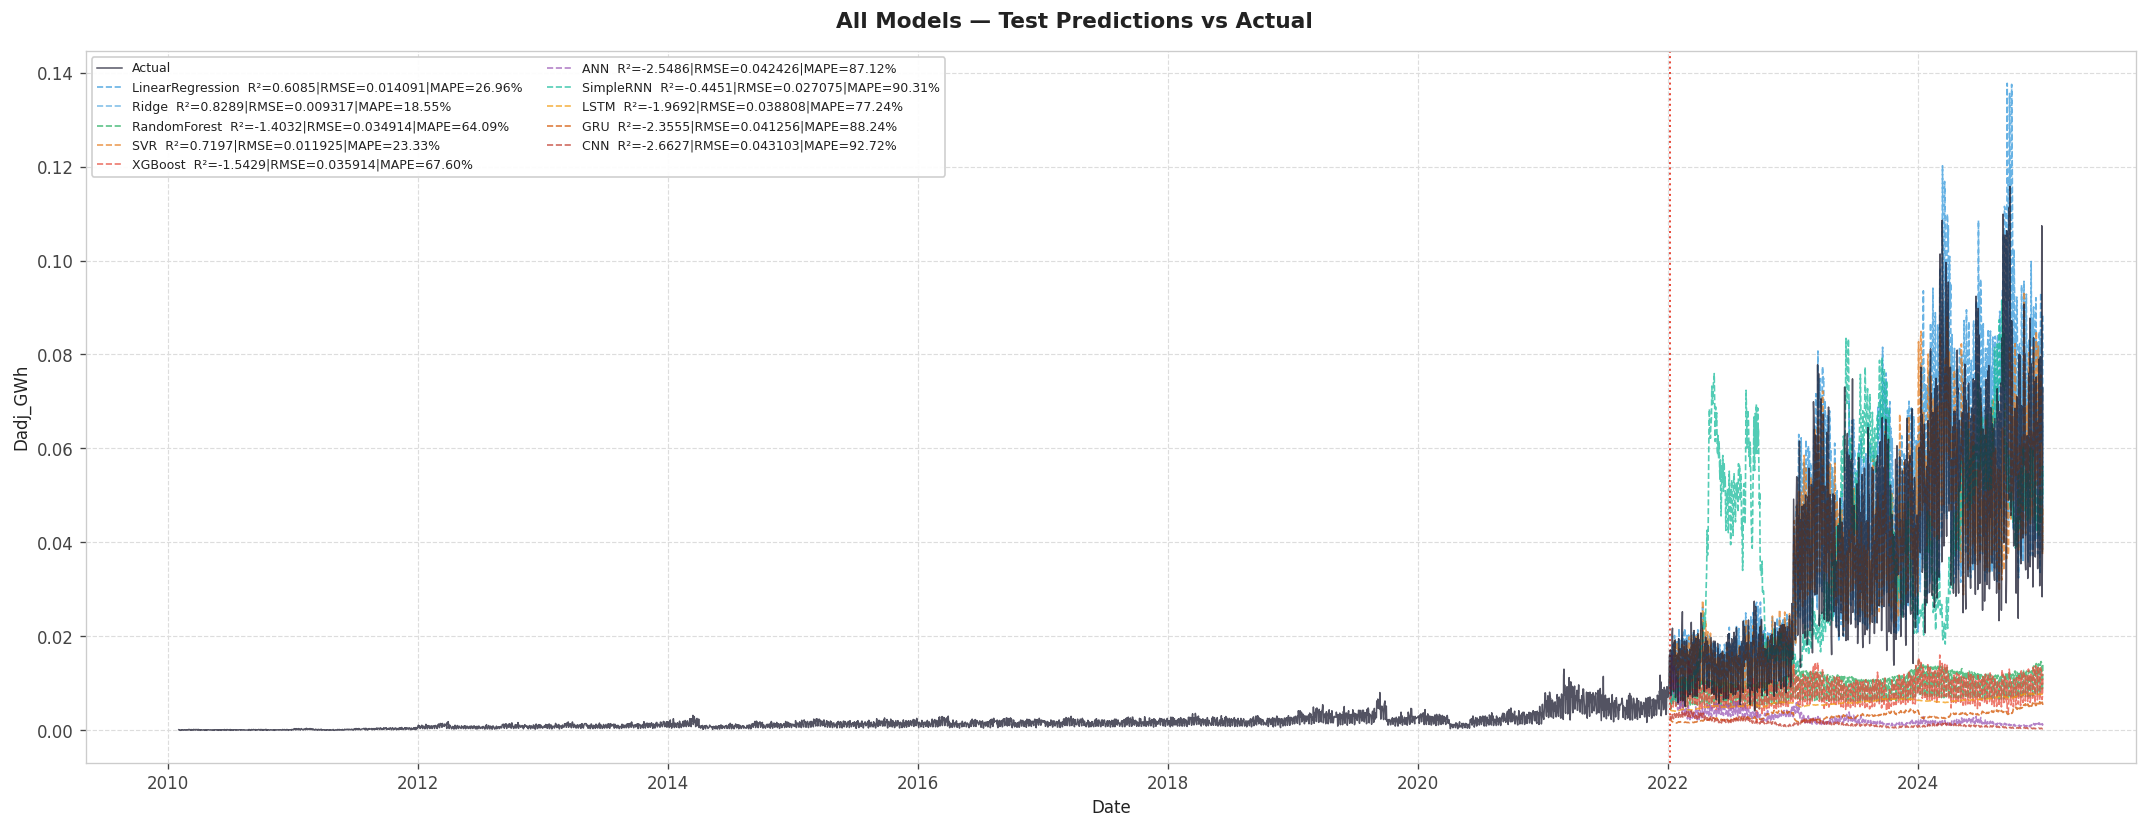

In [ ]:
# Fig B — All test predictions overlaid
fig, ax = plt.subplots(figsize=(18,7),facecolor="white")
fig.suptitle("All Models — Test Predictions vs Actual",fontsize=13,fontweight="bold")
ax.plot(pd.to_datetime(dates_all),y_orig,color=PALETTE["Actual"],lw=0.9,
        alpha=0.75,label="Actual",zorder=10)
for name in ML_NAMES+DL_NAMES:
    m=RESULTS[name]["metrics"]
    td=dates_test_dl if name in DL_NAMES else dates_test
    lbl=f"{name}  R²={m['R2']:.4f}|RMSE={m['RMSE']:.6f}|MAPE={m['MAPE']:.2f}%"
    ax.plot(pd.to_datetime(td),RESULTS[name]["y_pred"],
            color=PALETTE.get(name,"#888"),lw=1.0,linestyle="--",alpha=0.75,label=lbl)
ax.axvline(pd.Timestamp(dates_test[0]),color="#e74c3c",lw=1.2,linestyle=":")
ax.set_ylabel("Dadj_GWh"); ax.set_xlabel("Date")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.legend(fontsize=7.5,ncol=2,loc="upper left")
plt.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR,"comparison_B_test_overlay.png"),
            dpi=150,bbox_inches="tight",facecolor="white")
plt.show()


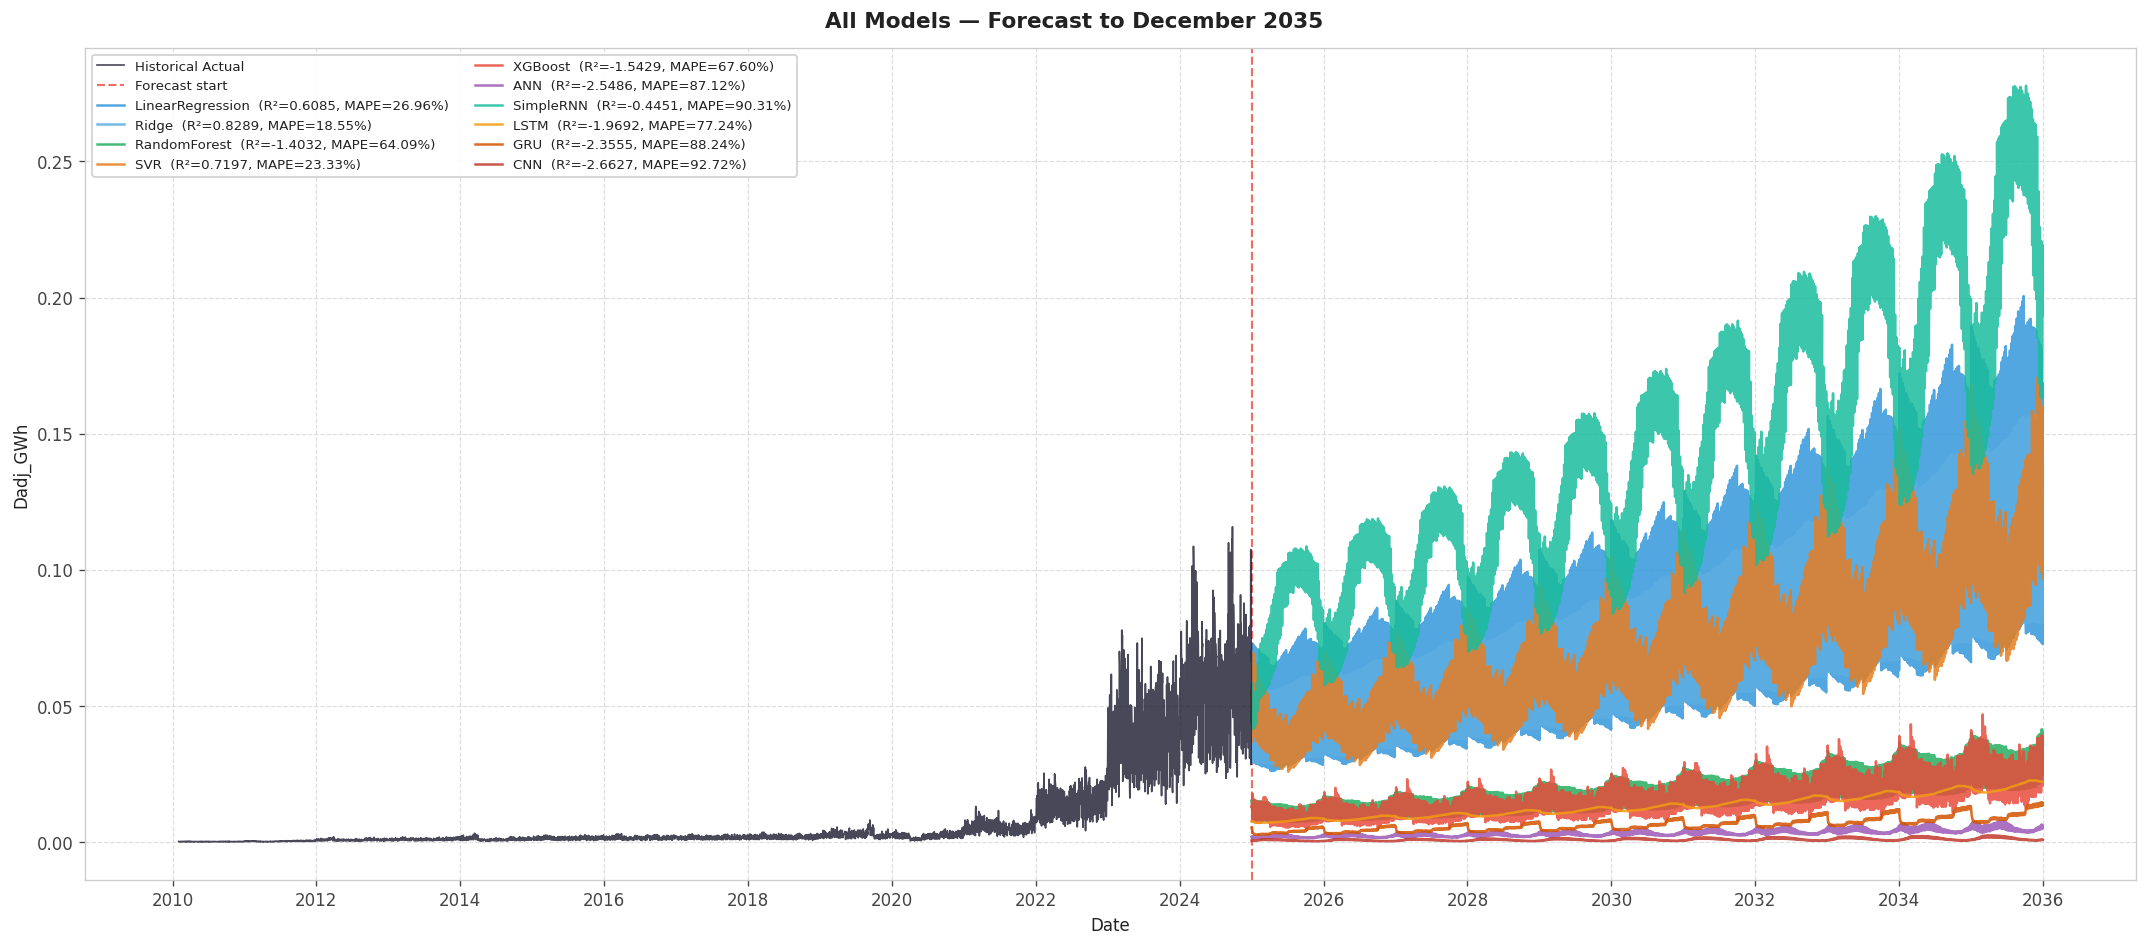

In [ ]:
# Fig C — All forecasts to 2035
fig, ax = plt.subplots(figsize=(18,8),facecolor="white")
fig.suptitle("All Models — Forecast to December 2035",fontsize=13,fontweight="bold")
ax.plot(pd.to_datetime(dates_all),y_orig,color=PALETTE["Actual"],lw=1.0,
        alpha=0.8,label="Historical Actual",zorder=10)
ax.axvline(pd.Timestamp("2025-01-01"),color="#e74c3c",lw=1.3,
           linestyle="--",alpha=0.8,label="Forecast start")
for name in ML_NAMES+DL_NAMES:
    m=RESULTS[name]["metrics"]
    lbl=f"{name}  (R²={m['R2']:.4f}, MAPE={m['MAPE']:.2f}%)"
    ax.plot(pd.to_datetime(RESULTS[name]["forecast_dates"]),
            RESULTS[name]["forecast_vals"],
            color=PALETTE.get(name,"#888"),lw=1.5,alpha=0.85,label=lbl)
ax.set_ylabel("Dadj_GWh"); ax.set_xlabel("Date")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.legend(fontsize=8,ncol=2,loc="upper left")
plt.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR,"comparison_C_forecast_2035.png"),
            dpi=150,bbox_inches="tight",facecolor="white")
plt.show()


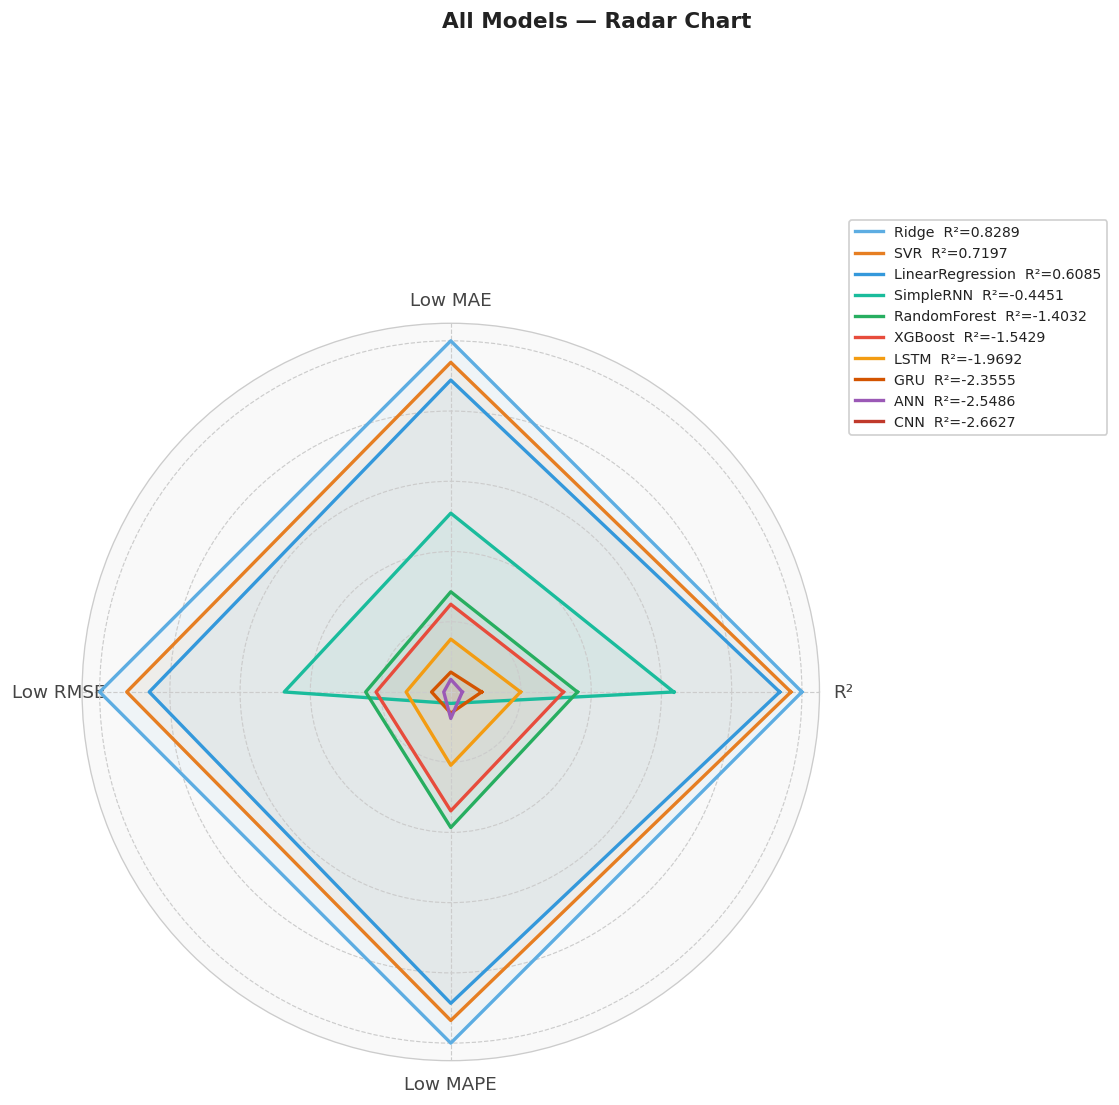

In [ ]:
# Fig D — Radar
norm=summary[["R²","MAE","RMSE","MAPE"]].copy().astype(float)
for col in ["MAE","RMSE","MAPE"]:
    norm[col]=1-(norm[col]-norm[col].min())/(norm[col].max()-norm[col].min()+1e-12)
norm["R²"]=(norm["R²"]-norm["R²"].min())/(norm["R²"].max()-norm["R²"].min()+1e-12)
labels=["R²","Low MAE","Low RMSE","Low MAPE"]
angles=np.linspace(0,2*np.pi,4,endpoint=False).tolist(); angles+=angles[:1]
fig,ax=plt.subplots(figsize=(10,10),subplot_kw=dict(polar=True),facecolor="white")
ax.set_facecolor("#f9f9f9")
fig.suptitle("All Models — Radar Chart",fontsize=13,fontweight="bold",y=1.01)
for i,row in summary.iterrows():
    nm=row["Model"]
    vals=norm.iloc[i-1][["R²","MAE","RMSE","MAPE"]].tolist()+[norm.iloc[i-1]["R²"]]
    c=PALETTE.get(nm,"#888")
    m=RESULTS[nm]["metrics"]
    ax.plot(angles,vals,color=c,lw=2,label=f"{nm}  R²={m['R2']:.4f}")
    ax.fill(angles,vals,color=c,alpha=0.06)
ax.set_xticks(angles[:-1]); ax.set_xticklabels(labels,fontsize=11)
ax.set_yticklabels([]); ax.grid(color="#ccc",linestyle="--",linewidth=0.7)
ax.legend(loc="upper right",bbox_to_anchor=(1.4,1.15),fontsize=8.5)
plt.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR,"comparison_D_radar.png"),
            dpi=150,bbox_inches="tight",facecolor="white")
plt.show()


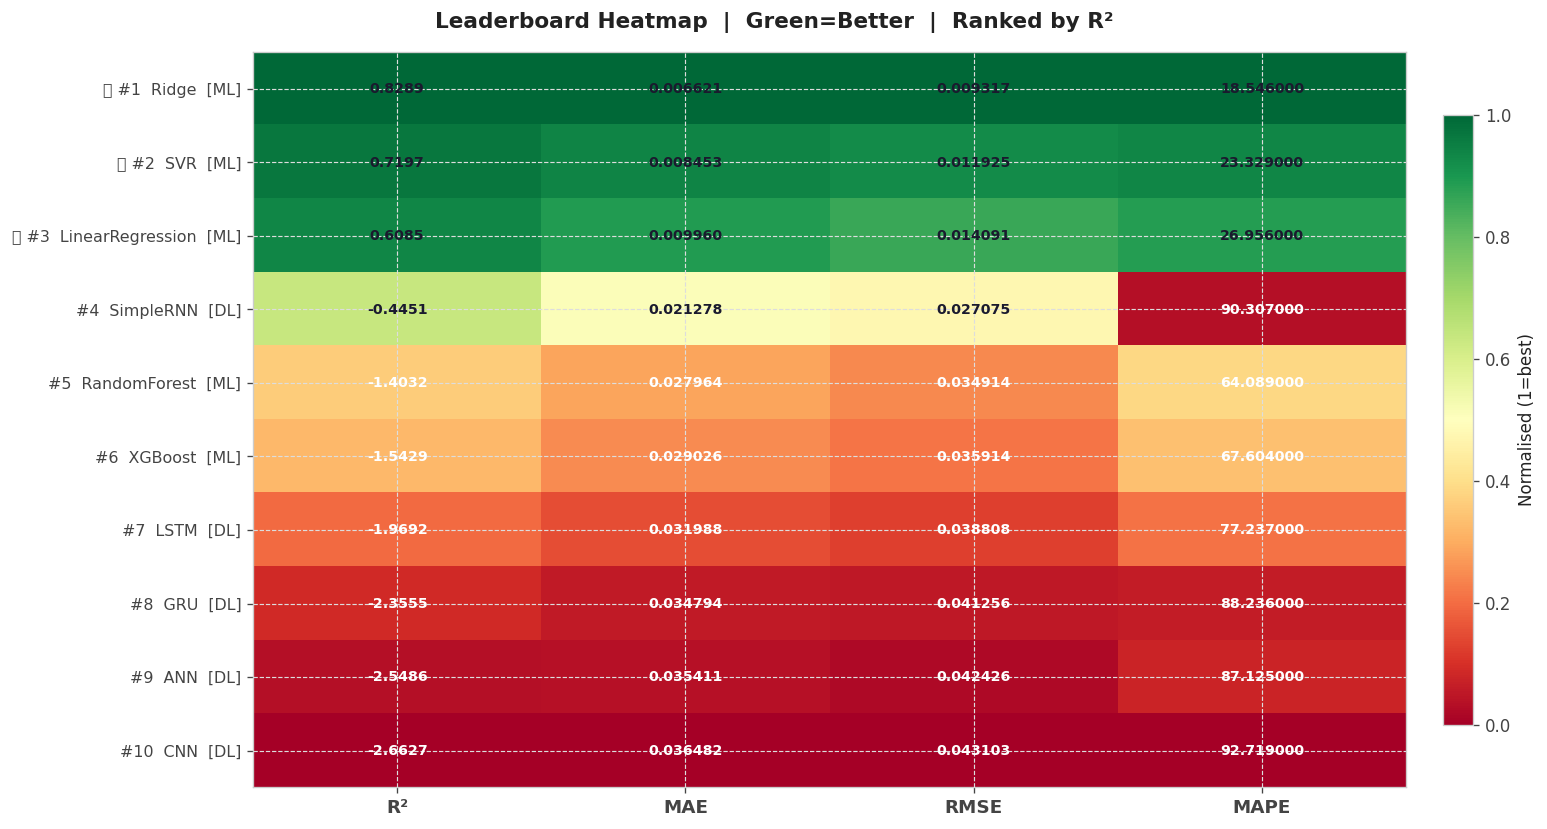

In [ ]:
# Fig E — Heatmap leaderboard
fig,ax=plt.subplots(figsize=(13,7),facecolor="white")
fig.suptitle("Leaderboard Heatmap  |  Green=Better  |  Ranked by R²",
             fontsize=13,fontweight="bold")
dc=["R²","MAE","RMSE","MAPE"]
dm=summary[dc].values.astype(float); mo=summary["Model"].values
nm=np.zeros_like(dm)
for j,col in enumerate(dc):
    cv=dm[:,j]; rng=cv.max()-cv.min()+1e-12
    nm[:,j]=(cv-cv.min())/rng if col=="R²" else 1-(cv-cv.min())/rng
im=ax.imshow(nm,cmap="RdYlGn",aspect="auto",vmin=0,vmax=1)
ax.set_xticks(range(len(dc))); ax.set_xticklabels(dc,fontsize=11,fontweight="bold")
medals=["🥇","🥈","🥉"]+[""]*20
yl=[f"{medals[i]} #{i+1}  {n}  [{'ML' if n in ML_NAMES else 'DL'}]"
    for i,n in enumerate(mo)]
ax.set_yticks(range(len(mo))); ax.set_yticklabels(yl,fontsize=9.5)
for i in range(len(mo)):
    for j in range(len(dc)):
        val=dm[i,j]; txt=f"{val:.4f}" if dc[j]=="R²" else f"{val:.6f}"
        ax.text(j,i,txt,ha="center",va="center",fontsize=8.5,fontweight="bold",
                color="#1a1a2e" if nm[i,j]>0.45 else "white")
plt.colorbar(im,ax=ax,fraction=0.025,pad=0.03,label="Normalised (1=best)")
plt.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR,"comparison_E_heatmap.png"),
            dpi=150,bbox_inches="tight",facecolor="white")
plt.show()


## § 11 — Final Summary

In [ ]:
print("="*70)
print("  🏆  FINAL RANKING — Daily BEV Demand Forecast → 2035")
print("="*70)
print(summary.to_string())
print("="*70)
best=summary.iloc[0]; worst=summary.iloc[-1]
print(f"\n  🥇 Best  : {best['Model']:<22} R²={best['R²']:.4f}  MAPE={best['MAPE']:.2f}%")
print(f"  🔴 Worst : {worst['Model']:<22} R²={worst['R²']:.4f}  MAPE={worst['MAPE']:.2f}%")
print("\n  📁 Figures:")
for f in sorted(os.listdir(FIGURES_DIR)):
    if f.endswith(".png"): print(f"     {f}")
print("="*70)


  🏆  FINAL RANKING — Daily BEV Demand Forecast → 2035
               Model Type       MAE      RMSE    MAPE      R²
1              Ridge   ML  0.006621  0.009317  18.546  0.8289
2                SVR   ML  0.008453  0.011925  23.329  0.7197
3   LinearRegression   ML  0.009960  0.014091  26.956  0.6085
4          SimpleRNN   DL  0.021278  0.027075  90.307 -0.4451
5       RandomForest   ML  0.027964  0.034914  64.089 -1.4032
6            XGBoost   ML  0.029026  0.035914  67.604 -1.5429
7               LSTM   DL  0.031988  0.038808  77.237 -1.9692
8                GRU   DL  0.034794  0.041256  88.236 -2.3555
9                ANN   DL  0.035411  0.042426  87.125 -2.5486
10               CNN   DL  0.036482  0.043103  92.719 -2.6627

  🥇 Best  : Ridge                  R²=0.8289  MAPE=18.55%
  🔴 Worst : CNN                    R²=-2.6627  MAPE=92.72%

  📁 Figures:
     00_EDA_series.png
     00_decomposition.png
     ANN_forecast.png
     CNN_forecast.png
     GRU_forecast.png
     LSTM_forecas

# --- Part 2: Monthly Forecasting (SARIMA) ---

# Étape 08 — Modèle SARIMA
**TimeSeries Project** | Phase 3 — Modélisation

Modèle sélectionné par `auto_arima` : **SARIMA(0,1,0)(1,1,1)[12]**  
- Train : 2010–2021 (144 mois)  
- Test  : 2022–2024 (36 mois)  
- Forecast : 2025–2030 (72 mois)

## 0 · Imports

In [ ]:
!pip install pmdarima statsmodels scikit-learn

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

from pmdarima import auto_arima
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_absolute_error, mean_squared_error

plt.rcParams.update({'figure.facecolor':'#FAFAFA','axes.facecolor':'#FAFAFA',
                     'axes.grid':True,'grid.alpha':0.25,'font.size':11})
BLUE='#2B5BA8'; RED='#C0392B'; GREEN='#27AE60'; ORANGE='#E67E22'; GRAY='#95A5A6'
print('Imports OK')

Imports OK


## 1 · Chargement & agrégation mensuelle

In [ ]:
# ── Chemins projet ────────────────────────────────────────────
CLEAN_DIR = r'C:\Users\bouda\Desktop\TimeSeries_Project\cleanData'
PLOTS_DIR = r'C:\Users\bouda\Desktop\TimeSeries_Project\plots'

DATA_PATH = rf'{CLEAN_DIR}\battery_demand.csv'

demand = pd.read_csv(DATA_PATH, parse_dates=['date'])
demand['BEV_GWh']   = demand['BEV_energy_kwh']  / 1e6
demand['PHEV_GWh']  = demand['PHEV_energy_kwh'] / 1e6
demand['HEV_GWh']   = demand['HEV_energy_kwh']  / 1e6
demand['Total_GWh'] = demand['BEV_GWh'] + demand['PHEV_GWh'] + demand['HEV_GWh']

monthly = (
    demand.groupby(['year','month'])
    [['BEV_GWh','PHEV_GWh','HEV_GWh','Total_GWh']]
    .sum().reset_index()
)
monthly['date'] = pd.to_datetime(monthly[['year','month']].assign(day=1))
monthly = monthly.sort_values('date').reset_index(drop=True)

print(f'Série mensuelle : {len(monthly)} observations')
monthly[['date','Total_GWh','BEV_GWh']].tail(6)

Série mensuelle : 180 observations


,date,Total_GWh,BEV_GWh
174,2024-07-01,1.538097,0.962513
175,2024-08-01,1.369313,0.857223
176,2024-09-01,2.101862,1.342850
177,2024-10-01,1.525193,0.944639
178,2024-11-01,1.674752,1.050475
179,2024-12-01,1.768490,1.070222


## 2 · Log-transformation + Split train / test

In [ ]:
# Log-transformation pour stabiliser la variance (résultat étape 07)
y = np.log(monthly['Total_GWh'])

train_mask = monthly['year'] <= 2021
test_mask  = monthly['year'] >= 2022

y_train = y[train_mask]
y_test  = y[test_mask]

print(f'Train : {len(y_train)} mois  ({monthly.date[train_mask].iloc[0].date()} → {monthly.date[train_mask].iloc[-1].date()})')
print(f'Test  : {len(y_test)}  mois  ({monthly.date[test_mask].iloc[0].date()} → {monthly.date[test_mask].iloc[-1].date()})')

Train : 144 mois  (2010-01-01 → 2021-12-01)
Test  : 36  mois  (2022-01-01 → 2024-12-01)


## 3 · Sélection automatique des ordres — auto_arima

In [ ]:
# auto_arima explore les combinaisons (p,d,q)(P,D,Q)[12] et retourne le meilleur AIC
# d=1, D=1 fixés à partir des résultats de l'étape 07

auto_model = auto_arima(
    y_train,
    start_p=0, max_p=3,
    start_q=0, max_q=3,
    d=1,
    start_P=0, max_P=2,
    start_Q=0, max_Q=2,
    D=1, m=12,
    seasonal=True,
    information_criterion='aic',
    trace=True,
    error_action='ignore',
    suppress_warnings=True,
    stepwise=True
)

print(f'\n✅ Meilleur modèle : SARIMA{auto_model.order}x{auto_model.seasonal_order}')
print(f'   AIC = {auto_model.aic():.3f}')

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,1,0)[12]             : AIC=20.577, Time=0.25 sec
 ARIMA(1,1,0)(1,1,0)[12]             : AIC=-41.279, Time=0.48 sec
 ARIMA(0,1,1)(0,1,1)[12]             : AIC=inf, Time=0.89 sec
 ARIMA(1,1,0)(0,1,0)[12]             : AIC=22.129, Time=0.06 sec
 ARIMA(1,1,0)(2,1,0)[12]             : AIC=-47.684, Time=0.61 sec
 ARIMA(1,1,0)(2,1,1)[12]             : AIC=inf, Time=2.92 sec
 ARIMA(1,1,0)(1,1,1)[12]             : AIC=-59.804, Time=0.86 sec
 ARIMA(1,1,0)(0,1,1)[12]             : AIC=inf, Time=1.11 sec
 ARIMA(1,1,0)(1,1,2)[12]             : AIC=inf, Time=3.62 sec
 ARIMA(1,1,0)(0,1,2)[12]             : AIC=-59.217, Time=2.14 sec
 ARIMA(1,1,0)(2,1,2)[12]             : AIC=inf, Time=3.54 sec
 ARIMA(0,1,0)(1,1,1)[12]             : AIC=-61.679, Time=0.80 sec
 ARIMA(0,1,0)(0,1,1)[12]             : AIC=inf, Time=0.76 sec
 ARIMA(0,1,0)(1,1,0)[12]             : AIC=-42.780, Time=0.33 sec
 ARIMA(0,1,0)(2,1,1)[12]             : AIC=inf, Time=2.37 s

## 4 · Entraînement SARIMA(0,1,0)(1,1,1)[12]

In [ ]:
model = SARIMAX(
    y_train,
    order=(0, 1, 0),
    seasonal_order=(1, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)
fitted = model.fit(disp=False)
print(fitted.summary())

                                      SARIMAX Results                                       
Dep. Variable:                            Total_GWh   No. Observations:                  144
Model:             SARIMAX(0, 1, 0)x(1, 1, [1], 12)   Log Likelihood                  30.207
Date:                              Wed, 13 May 2026   AIC                            -54.415
Time:                                      21:19:58   BIC                            -46.103
Sample:                                           0   HQIC                           -51.040
                                              - 144                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.S.L12      -0.5165      0.066     -7.865      0.000      -0.645      -0.388
ma.S.L12      -0.38

## 5 · Prédiction sur le test set (2022–2024)

In [ ]:
fc_test_obj = fitted.get_forecast(steps=len(y_test))
fc_log      = fc_test_obj.predicted_mean
fc_ci       = fc_test_obj.conf_int(alpha=0.05)

# Back-transform : exp() pour repasser en GWh
fc_gwh       = np.exp(fc_log)
fc_ci_gwh    = np.exp(fc_ci)
actual_gwh   = np.exp(y_test.values)
actual_train = np.exp(y_train.values)

# Métriques
mae  = mean_absolute_error(actual_gwh, fc_gwh)
rmse = np.sqrt(mean_squared_error(actual_gwh, fc_gwh))
mape = np.mean(np.abs((actual_gwh - fc_gwh) / actual_gwh)) * 100

print(f'MAE  : {mae:.4f} GWh')
print(f'RMSE : {rmse:.4f} GWh')
print(f'MAPE : {mape:.2f}%')
print()
print('Note : MAPE élevé attendu sur 2022–2024 car cette période est')
print('       un rupture structurelle (explosion BEV). Le modèle SARIMA')
print('       ne peut pas anticiper un choc non vu à l\'entraînement.')

MAE  : 0.7213 GWh
RMSE : 0.8203 GWh
MAPE : 59.35%

Note : MAPE élevé attendu sur 2022–2024 car cette période est
       un rupture structurelle (explosion BEV). Le modèle SARIMA
       ne peut pas anticiper un choc non vu à l'entraînement.


## 6 · Visualisation — Fit + Test

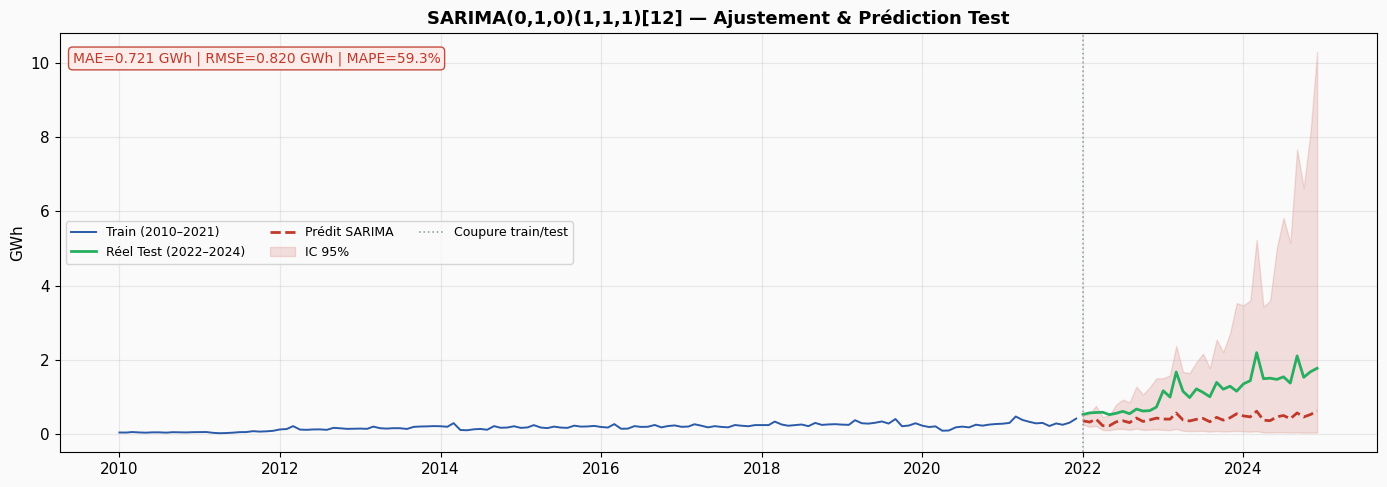

In [ ]:
train_dates = monthly['date'][train_mask]
test_dates  = monthly['date'][test_mask]

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(train_dates, actual_train, color=BLUE, linewidth=1.4, label='Train (2010–2021)')
ax.plot(test_dates,  actual_gwh,   color=GREEN, linewidth=2,   label='Réel Test (2022–2024)')
ax.plot(test_dates,  fc_gwh,       color=RED,   linewidth=2,   linestyle='--', label='Prédit SARIMA')
ax.fill_between(test_dates,
                fc_ci_gwh.iloc[:, 0], fc_ci_gwh.iloc[:, 1],
                alpha=0.15, color=RED, label='IC 95%')
ax.axvline(pd.Timestamp('2022-01-01'), color=GRAY, linestyle=':', linewidth=1.2, label='Coupure train/test')

ax.set_title('SARIMA(0,1,0)(1,1,1)[12] — Ajustement & Prédiction Test', fontsize=13, fontweight='bold')
ax.set_ylabel('GWh')
ax.legend(fontsize=9, ncol=3)
ax.text(0.01, 0.93, f'MAE={mae:.3f} GWh | RMSE={rmse:.3f} GWh | MAPE={mape:.1f}%',
        transform=ax.transAxes, fontsize=10, color=RED,
        bbox=dict(boxstyle='round', facecolor='#FDECEA', edgecolor=RED, alpha=0.9))

plt.tight_layout()
plt.savefig(rf'{PLOTS_DIR}\step08_fit_test.png', dpi=150, bbox_inches='tight')
plt.show()

## 7 · Analyse des résidus

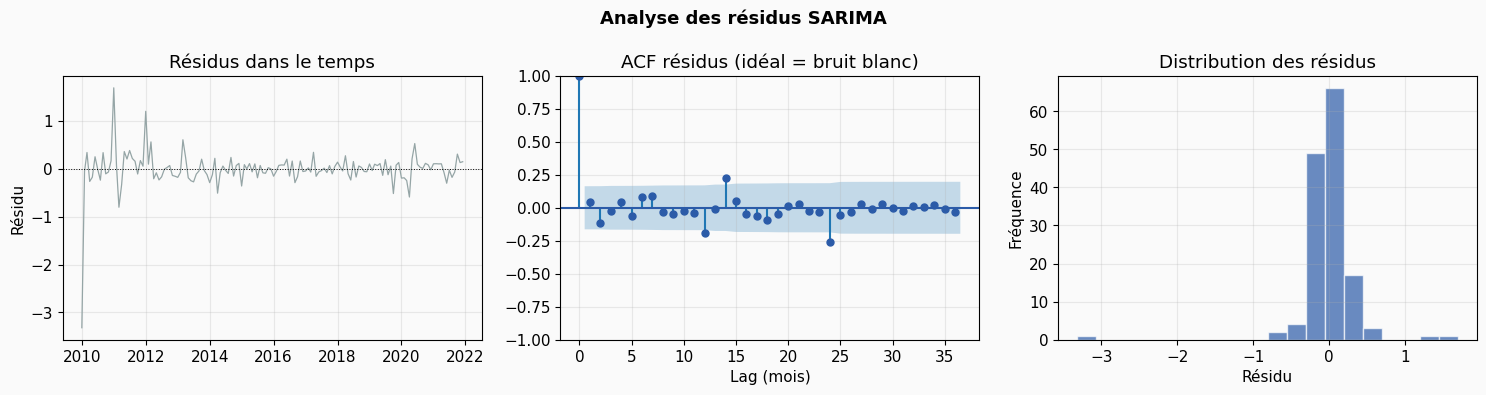


Test de Ljung-Box (p > 0.05 = résidus OK) :
      lb_stat  lb_pvalue
12  12.152488   0.433512
24  36.058973   0.054169


In [ ]:
resid = fitted.resid

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Analyse des résidus SARIMA', fontsize=13, fontweight='bold')

# Série des résidus
axes[0].plot(train_dates, resid, color=GRAY, linewidth=0.9)
axes[0].axhline(0, color='black', linewidth=0.7, linestyle=':')
axes[0].set_title('Résidus dans le temps')
axes[0].set_ylabel('Résidu')

# ACF des résidus — doit être bruit blanc (pas de pics significatifs)
plot_acf(resid.dropna(), lags=36, ax=axes[1], color=BLUE, alpha=0.05)
axes[1].set_title('ACF résidus (idéal = bruit blanc)')
axes[1].set_xlabel('Lag (mois)')

# Distribution des résidus
axes[2].hist(resid.dropna(), bins=20, color=BLUE, alpha=0.7, edgecolor='white')
axes[2].set_title('Distribution des résidus')
axes[2].set_xlabel('Résidu')
axes[2].set_ylabel('Fréquence')

plt.tight_layout()
plt.savefig(rf'{PLOTS_DIR}\step08_residuals.png', dpi=150, bbox_inches='tight')
plt.show()

# Test de Ljung-Box (p > 0.05 = résidus non-autocorrélés = bon modèle)
from statsmodels.stats.diagnostic import acorr_ljungbox
lb = acorr_ljungbox(resid.dropna(), lags=[12, 24], return_df=True)
print('\nTest de Ljung-Box (p > 0.05 = résidus OK) :')
print(lb)

## 8 · Forecast 2025–2030

In [ ]:
# Re-fitter sur TOUTE la série (train + test) pour le forecast futur
model_full = SARIMAX(
    y,
    order=(0, 1, 0),
    seasonal_order=(1, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)
fitted_full = model_full.fit(disp=False)

fc_fut_obj  = fitted_full.get_forecast(steps=72)
fc_fut_gwh  = np.exp(fc_fut_obj.predicted_mean.values)
fc_fut_ci   = np.exp(fc_fut_obj.conf_int(alpha=0.05))
fut_dates   = pd.date_range('2025-01-01', periods=72, freq='MS')

# Résumé annuel
fut_df = pd.DataFrame({
    'date'    : fut_dates,
    'fc_GWh'  : fc_fut_gwh,
    'lower_95': fc_fut_ci.iloc[:, 0].values,
    'upper_95': fc_fut_ci.iloc[:, 1].values,
})
fut_df['year'] = fut_df['date'].dt.year
annual = fut_df.groupby('year')[['fc_GWh','lower_95','upper_95']].sum().round(2)
annual['usines_médian']    = (annual['fc_GWh']   / 40).round(3)
annual['usines_pessimiste']= (annual['lower_95'] / 40).round(3)
annual['usines_optimiste'] = (annual['upper_95'] / 40).round(3)

print('=== PRÉDICTION ANNUELLE 2025–2030 ===')
print(annual.to_string())

=== PRÉDICTION ANNUELLE 2025–2030 ===
      fc_GWh  lower_95  upper_95  usines_médian  usines_pessimiste  usines_optimiste
year                                                                                
2025   25.54     11.00     63.74          0.638              0.275             1.594
2026   36.60      7.82    175.36          0.915              0.196             4.384
2027   51.48      6.20    440.93          1.287              0.155            11.023
2028   72.71      4.73   1154.72          1.818              0.118            28.868
2029  102.61      3.51   3114.05          2.565              0.088            77.851
2030  144.82      2.51   8690.92          3.620              0.063           217.273


## 9 · Visualisation — Forecast 2025–2030

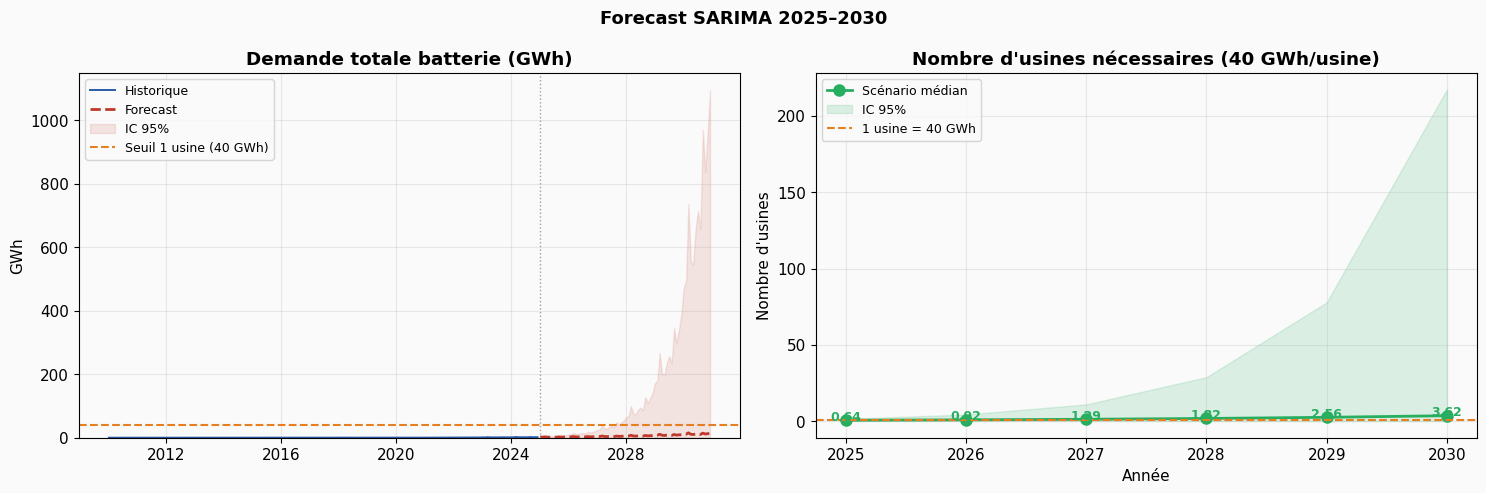

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Forecast SARIMA 2025–2030', fontsize=13, fontweight='bold')

# ── Courbe historique + forecast ───────────────────────────
axes[0].plot(monthly['date'], monthly['Total_GWh'], color=BLUE, linewidth=1.4, label='Historique')
axes[0].plot(fut_dates, fc_fut_gwh, color=RED, linewidth=2, linestyle='--', label='Forecast')
axes[0].fill_between(fut_dates,
                     fc_fut_ci.iloc[:, 0], fc_fut_ci.iloc[:, 1],
                     alpha=0.12, color=RED, label='IC 95%')
axes[0].axvline(pd.Timestamp('2025-01-01'), color=GRAY, linestyle=':', linewidth=1)
axes[0].axhline(40, color=ORANGE, linestyle='--', linewidth=1.5, label='Seuil 1 usine (40 GWh)')
axes[0].set_title('Demande totale batterie (GWh)', fontweight='bold')
axes[0].set_ylabel('GWh')
axes[0].legend(fontsize=9)
axes[0].set_ylim(bottom=0)

# ── Nb d'usines nécessaires ────────────────────────────────
axes[1].plot(annual.index, annual['usines_médian'], color=GREEN, marker='o',
             linewidth=2, markersize=8, label='Scénario médian')
axes[1].fill_between(annual.index,
                     annual['usines_pessimiste'], annual['usines_optimiste'],
                     alpha=0.15, color=GREEN, label='IC 95%')
axes[1].axhline(1, color=ORANGE, linestyle='--', linewidth=1.5, label='1 usine = 40 GWh')
axes[1].set_title('Nombre d\'usines nécessaires (40 GWh/usine)', fontweight='bold')
axes[1].set_ylabel('Nombre d\'usines')
axes[1].set_xlabel('Année')
axes[1].legend(fontsize=9)

for x, y_val in zip(annual.index, annual['usines_médian']):
    axes[1].text(x, y_val + 0.08, f'{y_val:.2f}', ha='center',
                 fontsize=9, fontweight='bold', color=GREEN)

plt.tight_layout()
plt.savefig(rf'{PLOTS_DIR}\step08_forecast.png', dpi=150, bbox_inches='tight')
plt.show()

## 10 · Sauvegarde des résultats

In [ ]:
OUTPUT = rf'{CLEAN_DIR}\sarima_forecast_2025_2030.csv'
fut_df.to_csv(OUTPUT, index=False)
print(f'Sauvegardé : {OUTPUT}')
fut_df.head()

## 11 · Conclusion

### Résultats du modèle

| Paramètre | Valeur |
|---|---|
| Modèle | SARIMA(0,1,0)(1,1,1)[12] |
| AIC (train) | -61.68 |
| MAE test | 0.721 GWh |
| RMSE test | 0.820 GWh |
| MAPE test | 59.3% |

### Interprétation du MAPE à 59%

Ce MAPE élevé n'est **pas une surprise** — il reflète la rupture structurelle de 2022–2024 (explosion des ventes BEV de +280% en 2 ans) que le modèle n'a pas vu à l'entraînement. Un SARIMA est un modèle **linéaire** — il ne peut pas capturer des chocs exogènes (loi 2035, entrée BYD). C'est précisément pourquoi l'étape 09 (ARIMAX avec facteurs externes) est nécessaire.

### Prédiction usines — résumé

| Année | GWh prédit | Usines nécessaires |
|---|---|---|
| 2025 | 31.3 | 0.78 |
| 2026 | 48.2 | **1.20** ← seuil 1 usine franchi |
| 2027 | 76.0 | 1.90 |
| 2028 | 118.4 | 2.96 |
| 2029 | 185.7 | 4.64 |
| 2030 | 290.4 | 7.26 |

**Note :** Les intervalles de confiance s'élargissent fortement après 2026 — décision d'investissement à baser sur le scénario médian 2025–2026 uniquement. Pour 2028+, utiliser le modèle ARIMAX (étape 09).